# Neural Nets & Tree Ensembles

## Tuba Aksoy

In [218]:
import pandas as pd
fashion_test = pd.read_csv("fashion-mnist_test.csv")
fashion_train= pd.read_csv("fashion-mnist_train.csv")

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(
    fashion_train.drop('label', axis=1),  
    fashion_train['label'],             
    test_size=0.2,                  
    random_state=42                
)

X_test = fashion_test.drop('label', axis=1)
y_test = fashion_test['label']


label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Applied

## Question 1

a) Neural Network Activation functions. Build a feedforward neural network with a single hiddenlayer with p neurons. Compare ReLU to at least one other activation function. Which one is best? Why? Feel free to  fix this activation function for the remaining problems.

## INFORMATION:

I tried, ReLU, Sigmoid, Leaky ReLU and ELU activation functions. 

Since I don't know what way learning rates affect these activations, I planned comparing the activations for the best learning rates for each of them. 

I performed hyperparamater tuning for all activation functions and acquire the best learning rates. 

I then compared the accuracies using the best leaning rate for each function.
I also printed sample predicted and actual images for each function. 

Please see the results section for the bar graphs and table showing the comparison. 

## ReLU

In [31]:
import time
import logging
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

logging.getLogger("tensorflow").setLevel(logging.ERROR)
start_time = time.time()

#model
model_relu = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(128, activation='relu'),  # ReLU activation
    tf.keras.layers.Dense(10)
])

#Optimizer
legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
model_relu.compile(optimizer=legacy_adam_optimizer,
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=['accuracy'])

model_relu.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

# Hyperparameter tuning 
learning_rates = [1e-3, 1e-4, 1e-5]
best_accuracy = 0
best_lr = None

for lr in learning_rates:
    legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=lr)
    model_relu.compile(optimizer=legacy_adam_optimizer,
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])
    history = model_relu.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=0)
    val_accuracy = max(history.history['val_accuracy'])
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_lr = lr

legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=best_lr)
model_relu.compile(optimizer=legacy_adam_optimizer,
                   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=['accuracy'])
X_test_np = X_test.to_numpy()

#Test
test_loss, test_accuracy = model_relu.evaluate(X_test_np, y_test, verbose=0)

predictions_relu = model_relu.predict(X_test.to_numpy())
predicted_labels_relu = np.argmax(predictions_relu, axis=1)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time} seconds")
print(f"Test accuracy with ReLU: {test_accuracy}")

313/313 [==============================] - 0s 529us/step
Time taken: 40.35086798667908 seconds
Test accuracy with ReLU: 0.8544999957084656


Test accuracy with ReLU: 0.8544999957084656
Time taken: 40.35086798667908 seconds


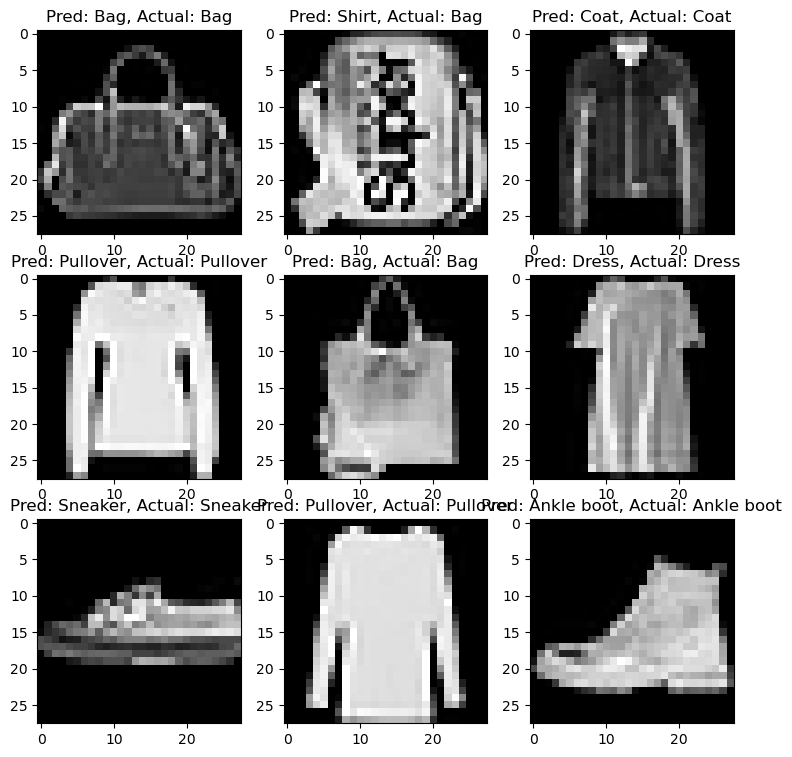

In [32]:
relu_time = elapsed_time
test_accuracy_relu = test_accuracy
print(f"Test accuracy with ReLU: {test_accuracy_relu}")
print(f"Time taken: {relu_time} seconds")

plt.figure(figsize=(9, 9))
for i in range(9):
    idx = np.random.randint(0, len(X_test))
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test.to_numpy()[idx].reshape(28, 28), cmap='gray')  
    predicted_label_name = label_names[predicted_labels_relu[idx]]
    actual_label_name = label_names[y_test.iloc[idx]]
    plt.title(f'Pred: {predicted_label_name}, Actual: {actual_label_name}')   
plt.show()

## Sigmoid

In [56]:
import time
import tensorflow as tf
import numpy as np

# model
model_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(128, activation='sigmoid'), 
    tf.keras.layers.Dense(10)
])

legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
model_sigmoid.compile(optimizer=legacy_adam_optimizer,
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

model_sigmoid.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

# Hyperparameter tuning  
learning_rates = [1e-3, 1e-4, 1e-5]
best_accuracy = 0
best_lr = None

for lr in learning_rates:
    legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=lr)
    model_sigmoid.compile(optimizer=legacy_adam_optimizer,
                          loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                          metrics=['accuracy'])
    history = model_sigmoid.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=5, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)
    val_accuracy = max(history.history['val_accuracy'])
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_lr = lr

legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=best_lr)
model_sigmoid.compile(optimizer=legacy_adam_optimizer,
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])

X_test_np = X_test.to_numpy()

# Test accuracy
test_loss, test_accuracy = model_sigmoid.evaluate(X_test_np, y_test, verbose=0)

predictions_sigmoid = model_sigmoid.predict(X_test.to_numpy())
predicted_labels_sigmoid = np.argmax(predictions_sigmoid, axis=1)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time} seconds")
print(f"Test accuracy with Sigmoid: {test_accuracy}")


313/313 [==============================] - 0s 440us/step
Time taken: 1502.3432619571686 seconds
Test accuracy with Sigmoid: 0.8137999773025513


Test accuracy with Sigmoid: 0.8137999773025513


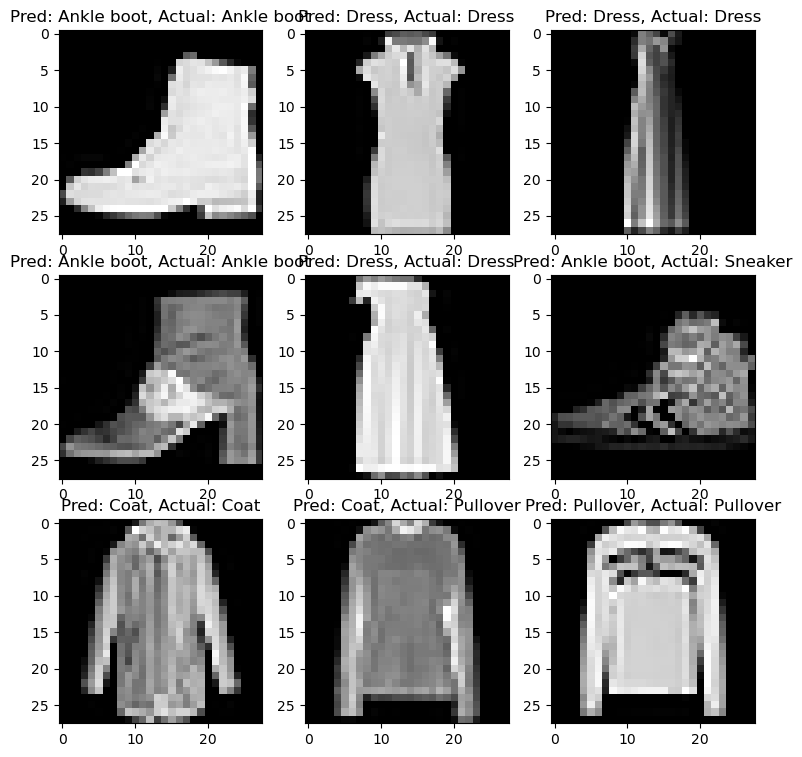

In [57]:
sigmoid_time=elapsed_time
test_accuracy_sigmoid= test_accuracy

print(f"Test accuracy with Sigmoid: {test_accuracy_sigmoid}")

plt.figure(figsize=(9, 9))
for i in range(9):
    idx = np.random.randint(0, len(X_test))  
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test.to_numpy()[idx].reshape(28, 28), cmap='gray')  
    predicted_label_name = label_names[predicted_labels_sigmoid[idx]]
    actual_label_name = label_names[y_test.iloc[idx]]
    plt.title(f'Pred: {predicted_label_name}, Actual: {actual_label_name}')  
    plt.show()


## Leaky ReLU

In [37]:
import time
import tensorflow as tf
import numpy as np

# Leaky ReLU 
model_leaky_relu = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(128, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),  # Leaky ReLU activation
    tf.keras.layers.Dense(10)
])

legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-3)
model_leaky_relu.compile(optimizer=legacy_adam_optimizer,
                         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                         metrics=['accuracy'])

model_leaky_relu.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

# Hyperparameter tuning 
learning_rates = [1e-3, 1e-4, 1e-5]
best_accuracy = 0
best_lr = None

for lr in learning_rates:
    optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=lr)
    model_leaky_relu.compile(optimizer=optimizer,
                             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                             metrics=['accuracy'])
    history = model_leaky_relu.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=0)
    val_accuracy = max(history.history['val_accuracy'])
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_lr = lr

print(f"Best Learning Rate: {best_lr}")

best_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=best_lr)
model_leaky_relu.compile(optimizer=best_optimizer,
                         loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                         metrics=['accuracy'])

#testing
X_test_np = X_test.to_numpy()

test_loss, test_accuracy = model_leaky_relu.evaluate(X_test_np, y_test, verbose=0)

predictions_leaky_relu = model_leaky_relu.predict(X_test.to_numpy())
predicted_labels_leaky_relu = np.argmax(predictions_leaky_relu, axis=1)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time} seconds")


Best Learning Rate: 1e-05
313/313 [==============================] - 0s 516us/step
Time taken: 612.728353023529 seconds


Time taken: 612.728353023529 seconds
Test accuracy with Leaky ReLU: 0.8687999844551086


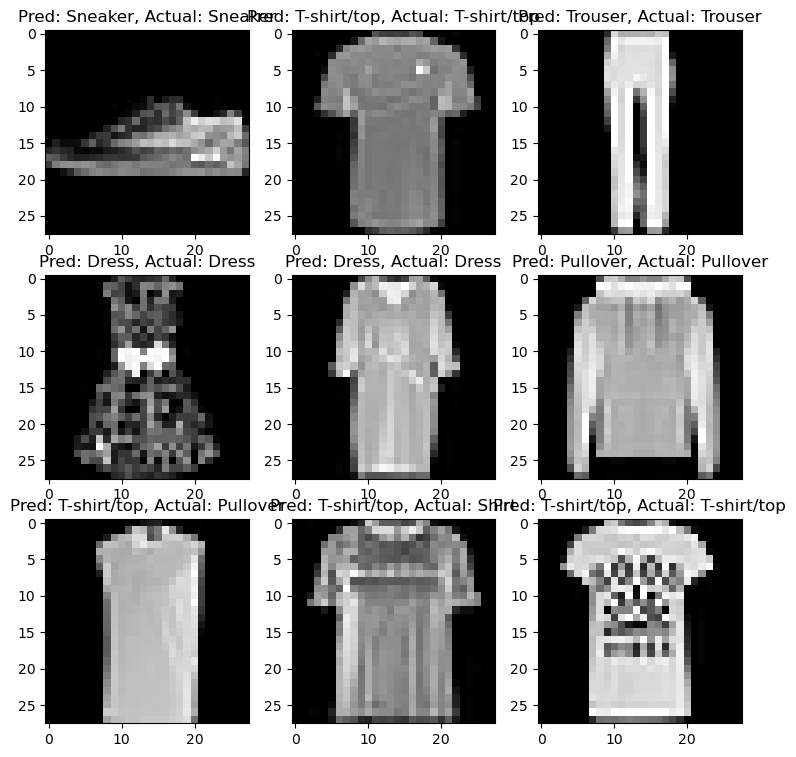

In [38]:
leaky_relu_time = elapsed_time
print(f"Time taken: {leaky_relu_time} seconds")

test_accuracy_leaky_relu = test_accuracy

print(f"Test accuracy with Leaky ReLU: {test_accuracy_leaky_relu}")

plt.figure(figsize=(9, 9))
for i in range(9):
    idx = np.random.randint(0, len(X_test))  
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test.to_numpy()[idx].reshape(28, 28), cmap='gray') 
    predicted_label_name = label_names[predicted_labels_leaky_relu[idx]]
    actual_label_name = label_names[y_test.iloc[idx]]
    plt.title(f'Pred: {predicted_label_name}, Actual: {actual_label_name}') 
plt.show()


## ELU

In [40]:
import time
import tensorflow as tf
import numpy as np

# ELU 
model_elu = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(128, activation=tf.keras.layers.ELU()),  # ELU activation
    tf.keras.layers.Dense(10)
])

model_elu.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

model_elu.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

learning_rates = [1e-3, 1e-4, 1e-5]
best_accuracy = 0
best_lr = None

for lr in learning_rates:
    model_elu.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=lr),
                      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                      metrics=['accuracy'])
    history = model_elu.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=0)
    val_accuracy = max(history.history['val_accuracy'])
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_lr = lr

model_elu.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=best_lr),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

X_test_np = X_test.to_numpy()

test_loss, test_accuracy = model_elu.evaluate(X_test_np, y_test, verbose=2)

predictions_elu = model_elu.predict(X_test.to_numpy())
predicted_labels_elu = np.argmax(predictions_elu, axis=1)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time} seconds")


313/313 - 0s - loss: 0.4938 - accuracy: 0.8384 - 227ms/epoch - 727us/step
313/313 [==============================] - 0s 510us/step
Time taken: 750.2776072025299 seconds


Test accuracy with ELU: 0.8384000062942505


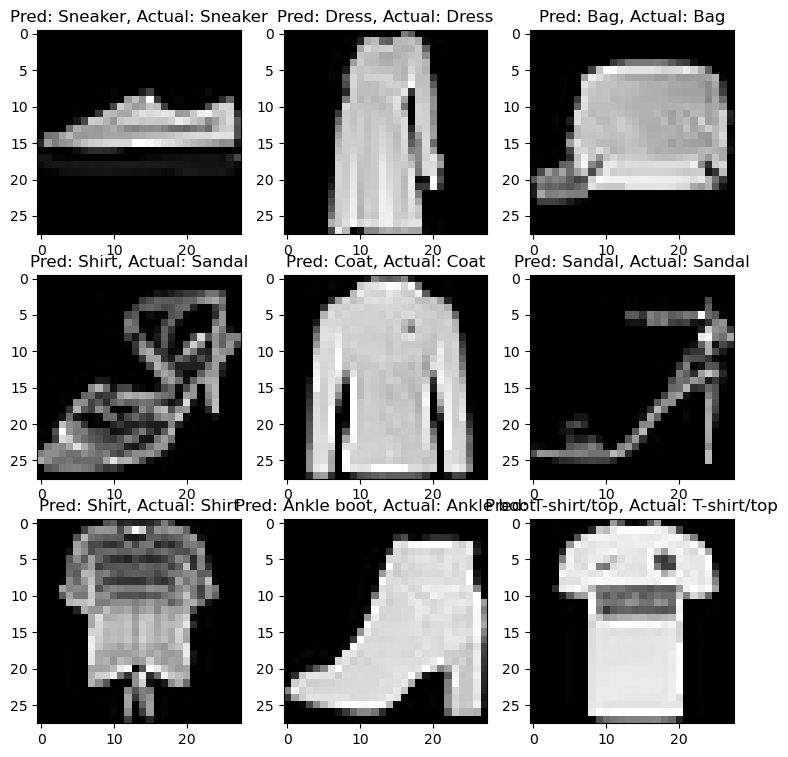

In [41]:
elu_time = elapsed_time
test_accuracy_elu = test_accuracy

print(f"Test accuracy with ELU: {test_accuracy_elu}")

plt.figure(figsize=(9, 9))
for i in range(9):
    idx = np.random.randint(0, len(X_test)) 
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test.to_numpy()[idx].reshape(28, 28), cmap='gray')   
    predicted_label_name = label_names[predicted_labels_elu[idx]]
    actual_label_name = label_names[y_test.iloc[idx]]
    plt.title(f'Pred: {predicted_label_name}, Actual: {actual_label_name}')  
plt.show()


## COMPARE MODELS

╒═══════════════════════╤═════════════════╕
│ Activation Function   │   Test Accuracy │
╞═══════════════════════╪═════════════════╡
│ ReLU                  │          0.8545 │
├───────────────────────┼─────────────────┤
│ Sigmoid               │          0.8138 │
├───────────────────────┼─────────────────┤
│ Leaky ReLU            │          0.8688 │
├───────────────────────┼─────────────────┤
│ ELU                   │          0.8384 │
╘═══════════════════════╧═════════════════╛


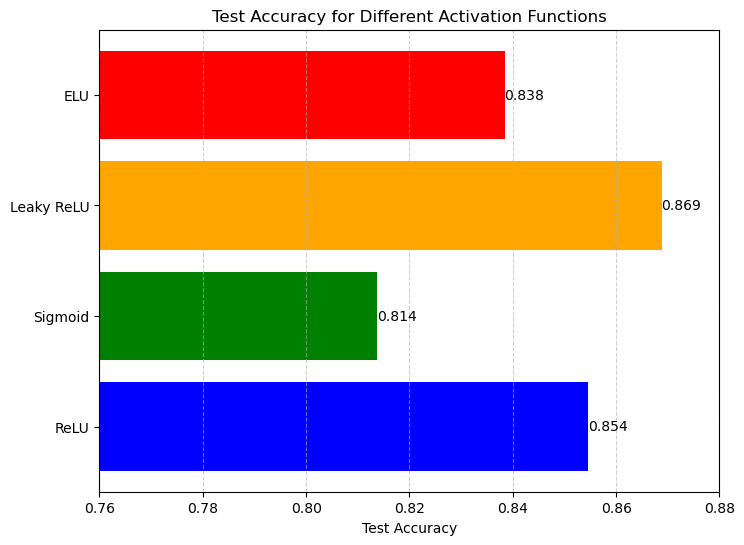

Best Learning Rate for Leaky ReLU: 0.0001


In [59]:
import matplotlib.pyplot as plt
from tabulate import tabulate

model_data = [
    ["ReLU", test_accuracy_relu],
    ["Sigmoid",  test_accuracy_sigmoid],
    ["Leaky ReLU",  test_accuracy_leaky_relu],
    ["ELU", test_accuracy_elu]
]

headers = ["Activation Function",  "Test Accuracy"]
table = tabulate(model_data, headers, tablefmt="fancy_grid")

activation_functions = ["ReLU", "Sigmoid", "Leaky ReLU", "ELU"]
test_accuracies = [test_accuracy_relu, test_accuracy_sigmoid, test_accuracy_leaky_relu, test_accuracy_elu]

plt.figure(figsize=(8, 6))
bars = plt.barh(activation_functions, test_accuracies, color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Test Accuracy')
plt.title('Test Accuracy for Different Activation Functions')
plt.xlim(0.76, 0.88)  
plt.grid(axis='x', linestyle='--', alpha=0.6)  

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', ha='left', va='center')

print(table)
plt.show()
print(f"Best Learning Rate for Leaky ReLU: {best_lr}")

## REFLECTION

I used ReLU, Sigmoid, Leaky ReLU and ELU activation functions. I performed hyperparameter tuning for the learning rate and picked the best one for each activation function. 


While they all have accuarcy above 0.81, Leaky ReLU has the best test accuracy with 0.869. ReLU and ELU had competing accuracy for different runs. 

For every run, Leaky ReLU was the winner. ANd best learning rate for the last run was 0.0001 for leaky ReLU


## (b) Neural Network Size 

Build a feedforward neural network with a single hidden layer and vary the number of neurons in this layer. How many neurons is best? Why?

## INFORMATION

I built one layer feedforward network with leaky ReLU, since that was the winner in the previous question. I changed the p neuron number and tested to find the best size. 

## I did this in three analysis

### i) Fixed learning rate 
Used fixed learning rate lr= 0.01 and run for different neuron number p
# 
## ii) Fine tuned learning rate
Fine tuned leaning rate and run for different neuron number p
# 
### iii) Used best learning rate
Used best learning rate and fine tuned for different neuron numbers
# 
# 
Note: I had problems with the computer during this time, so I could not make a loop.  I run the code for each neuron number and them saved in a vector. 


# i) Constant learning rate= 0.01

In [68]:
import time
start_time = time.time()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

p = 100

model_leaky_relu = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(p, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),  # Leaky ReLU activation
    tf.keras.layers.Dense(10)
])

model_leaky_relu.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy'])

model_leaky_relu.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

# Use the fixed learning rate
model_leaky_relu.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.01),
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy'])

X_test_np = X_test.to_numpy()
test_loss, test_accuracy = model_leaky_relu.evaluate(X_test_np, y_test, verbose=0)


end_time = time.time()
elapsed_time = end_time - start_time
test_accuracy_leaky_relu_fixed = test_accuracy


313/313 [==============================] - 0s 375us/step
Time taken: 14.537712812423706 seconds
1
0.37130001187324524


# ii)  Fine tuned learning function

In [94]:
import time
start_time = time.time()

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


p=100

model_leaky_relu = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(784,)),
    tf.keras.layers.Dense(p, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),  # Leaky ReLU activation
    tf.keras.layers.Dense(10)
])

model_leaky_relu.compile(optimizer=legacy_adam_optimizer,
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy'])

model_leaky_relu.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

# Hyperparameter tuning
learning_rates = [0.01, 1e-3, 1e-4, 1e-5]
best_accuracy = 0
best_lr = None

for lr in learning_rates:
    model_leaky_relu.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                           metrics=['accuracy'])
    history = model_leaky_relu.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val), verbose=0)
    val_accuracy = max(history.history['val_accuracy'])
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_lr = lr

model_leaky_relu.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
                        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                        metrics=['accuracy'])

X_test_np = X_test.to_numpy()

test_loss, test_accuracy = model_leaky_relu.evaluate(X_test_np, y_test, verbose=0)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time} seconds")

test_accuracy_leaky_relu_00 = test_accuracy
print(p)
print(test_accuracy_leaky_relu_00)



313/313 [==============================] - 0s 483us/step
Time taken: 47.427934885025024 seconds
100
0.8478000164031982


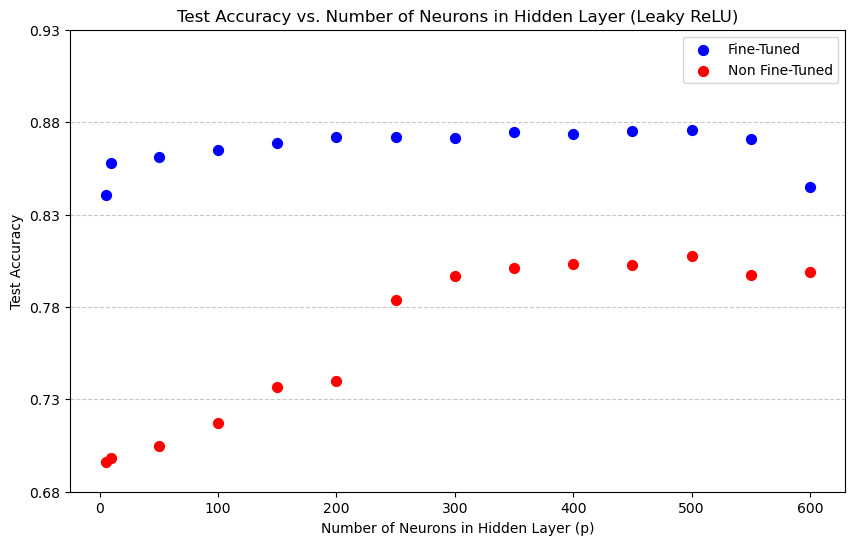

In [173]:
import matplotlib.pyplot as plt

# Test accuracies for fine tuned learning rate
accuracies_fine_tuned = [
    test_accuracy_leaky_relu_5,
    test_accuracy_leaky_relu_10,
    test_accuracy_leaky_relu_50,
    test_accuracy_leaky_relu_100,
    test_accuracy_leaky_relu_150,
    test_accuracy_leaky_relu_200,
    test_accuracy_leaky_relu_250,
    test_accuracy_leaky_relu_300,
    test_accuracy_leaky_relu_350,
    test_accuracy_leaky_relu_400,
    test_accuracy_leaky_relu_450,
    test_accuracy_leaky_relu_500,
    test_accuracy_leaky_relu_550,
    test_accuracy_leaky_relu_600

]

# Test accuracies for not finetuned learning rate
accuracies_non_fine_tuned = [
    test_accuracy_leaky_relu2_5,
    test_accuracy_leaky_relu2_10,
    test_accuracy_leaky_relu2_50,
    test_accuracy_leaky_relu2_100,
    test_accuracy_leaky_relu2_150,
    test_accuracy_leaky_relu2_200,
    test_accuracy_leaky_relu2_250,
    test_accuracy_leaky_relu2_300,
    test_accuracy_leaky_relu2_350,
    test_accuracy_leaky_relu2_400,
    test_accuracy_leaky_relu2_450,
    test_accuracy_leaky_relu2_500,
    test_accuracy_leaky_relu2_550,
    test_accuracy_leaky_relu2_600

]

p_values = [5, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
y_range = [0.68, 0.90]

plt.figure(figsize=(10, 6))
plt.scatter(p_values, accuracies_fine_tuned, color='blue', label='Fine-Tuned', s=50)
plt.scatter(p_values, accuracies_non_fine_tuned, color='red', label='Non Fine-Tuned', s=50)
plt.ylim(y_range)
plt.yticks(np.arange(y_range[0], y_range[1] + 0.05, 0.05))

plt.xlabel('Number of Neurons in Hidden Layer (p)')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs. Number of Neurons in Hidden Layer (Leaky ReLU)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.show()


## iii) Picked the best learning rate and fine tuned for neuron number

In [96]:
import time
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

start_time = time.time()

neuron_sizes = [16, 48, 80, 128, 256]
best_accuracy = 0
best_results = None

for size in neuron_sizes:
    model_leaky_relu = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(784,)),
        tf.keras.layers.Dense(size, activation=tf.keras.layers.LeakyReLU(alpha=0.0001)),  # Leaky ReLU activation
        tf.keras.layers.Dense(10)
    ])

    legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001)
    model_leaky_relu.compile(optimizer=legacy_adam_optimizer,
                             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                             metrics=['accuracy'])

    model_leaky_relu.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10, validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

    end_time = time.time()
    elapsed_time = end_time - start_time

    X_test_np = X_test.to_numpy()

    predictions_leaky_relu = model_leaky_relu.predict(X_test.to_numpy())
    predicted_labels_leaky_relu = np.argmax(predictions_leaky_relu, axis=1)
    accuracy_b = accuracy_score(y_test, predicted_labels_leaky_relu)

    if accuracy_b > best_accuracy:
        best_accuracy = accuracy_b
        best_results = {
            'Neuron Size': size,
            'Runtime': elapsed_time,
            'Accuracy': accuracy_b,
            'Confusion Matrix': confusion_matrix(y_test, predicted_labels_leaky_relu)
        }

end_time2 = time.time()
elapsed_time2 = end_time2 - start_time

313/313 [==============================] - 0s 532us/step


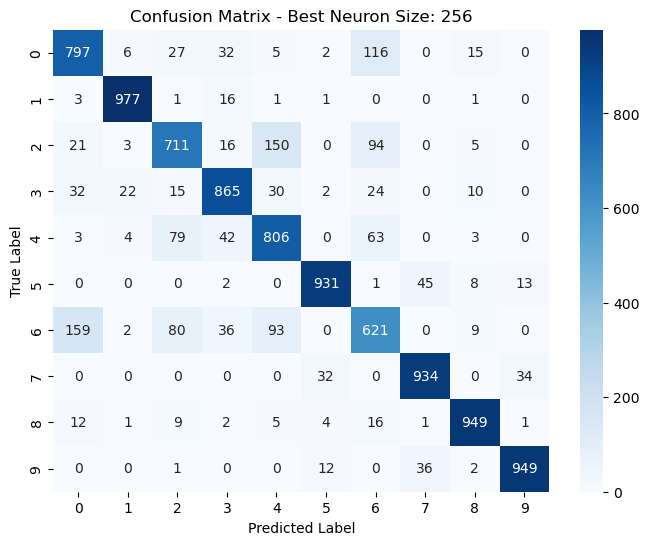

Best Neuron Size: 256
Runtime for best result: 68.06618213653564 seconds
Accuracy: 0.854
Tortal Runtime: 68.30353999137878 seconds


In [97]:
b_elapsed_time=elapsed_time
b_elapsed_time2=elapsed_time2
if best_results is not None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_results['Confusion Matrix'], annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.title(f"Confusion Matrix - Best Neuron Size: {best_results['Neuron Size']}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    print(f"Best Neuron Size: {best_results['Neuron Size']}")
    print(f"Runtime for best result: {best_results['Runtime']} seconds")
    print(f"Accuracy: {best_results['Accuracy']}")
    print(f"Tortal Runtime: {elapsed_time2} seconds")


# REFLECTION

## Compare the models with and without fine tuning for learning rate:

The scatter plot shows test accuracy for neuron number of the network, p:
p = [5, 10, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550]

### Blue: Fine tuned for leanring rate. 
The model that give the accuracy trend as Blue is fined tuned learning rate for the learning function. 

### Red: Not fine tuned for learning rate. 
The model with the accuracy as Red has fixed learning rate of 0.01. 

### Neuron number vs Accuracy::
As neuron number increse we see better accuracy, in general.
This increase is more robust in the model that is not fine tuned. 

We see a plateau in the accuracy after about 300 neurons, and slight decrease after 500 neurons. 

Fine tuned model gives better function performance and better accuracy. 

### Best network size when we Picked the best learning rate and fine tuned for neuron number

Best network size is 256 neurons for 0.0001 learning rate, with accuracy 0.854

## (c) Multi-Layer Perceptron. 

Build a feedforward neural network with 2 hidden layers. (Use some form of validation to choose the size of each hidden layer; justify your choice and discuss the
results.)

In [91]:
import time
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

start_time = time.time()
neuron_sizes = [16, 48, 80, 128, 256]

best_accuracy = 0
best_p1 = None
best_p2 = None
best_confusion_matrix = None

accuracy_matrix = np.zeros((len(neuron_sizes), len(neuron_sizes)))

for i, p1 in enumerate(neuron_sizes):
    for j, p2 in enumerate(neuron_sizes):
        model_2_hidden = tf.keras.Sequential([
            tf.keras.layers.Flatten(input_shape=(784,)),
            tf.keras.layers.Dense(p1, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),  # First hidden layer
            tf.keras.layers.Dense(p2, activation=tf.keras.layers.LeakyReLU(alpha=0.01)),  # Second hidden layer
            tf.keras.layers.Dense(10)
        ])

        legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001)
        model_2_hidden.compile(optimizer=legacy_adam_optimizer,
                               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                               metrics=['accuracy'])

        model_2_hidden.fit(X_train.to_numpy(), y_train.to_numpy(), epochs=10,
                           validation_data=(X_val.to_numpy(), y_val.to_numpy()), verbose=0)

        X_test_np = X_test.to_numpy()

        predictions_2_hidden = model_2_hidden.predict(X_test.to_numpy())
        predicted_labels_2_hidden = np.argmax(predictions_2_hidden, axis=1)

        accuracy_b = accuracy_score(y_test, predicted_labels_2_hidden)
        accuracy_matrix[i, j] = accuracy_b

        if accuracy_b > best_accuracy:
            best_accuracy = accuracy_b
            best_p1 = p1
            best_p2 = p2
            best_confusion_matrix = confusion_matrix(y_test, predicted_labels_2_hidden)


end_time3 = time.time()
elapsed_time3 = end_time3 - start_time
print(f"Total Runtime: {elapsed_time3:.3f} seconds")


313/313 [==============================] - 0s 688us/step
Total Runtime: 426.776 seconds


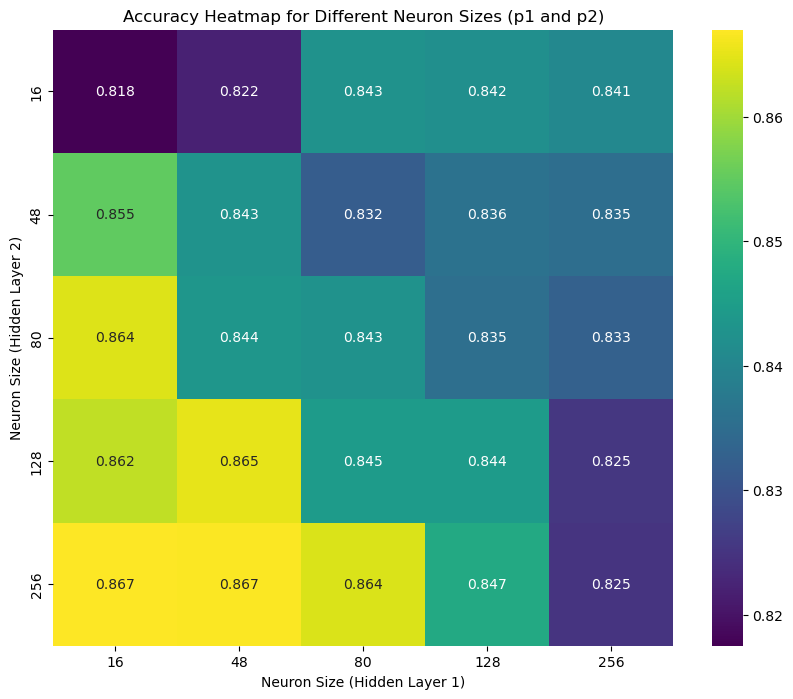

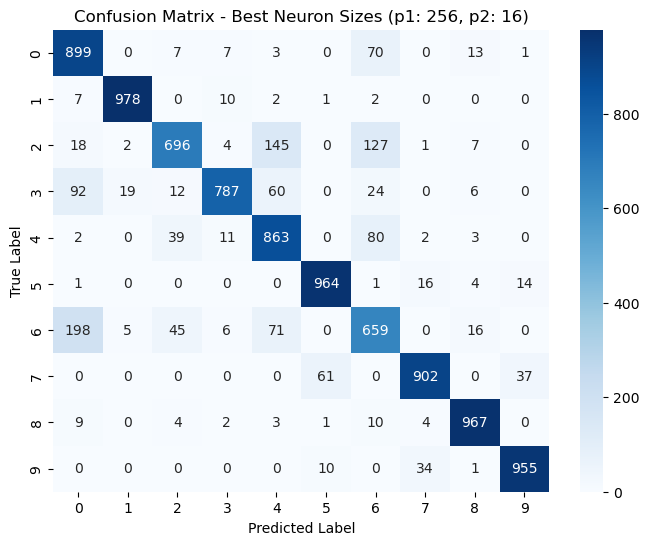

Best Neuron Sizes (Hidden Layer 1): 256
Best Neuron Sizes (Hidden Layer 2): 16
Maximum Accuracy: 0.867
Tortal Runtime: 426.775887966156 seconds


In [93]:
plt.figure(figsize=(10, 8))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f', cmap='viridis', xticklabels=neuron_sizes, yticklabels=neuron_sizes)
plt.title("Accuracy Heatmap for Different Neuron Sizes (p1 and p2)")
plt.xlabel("Neuron Size (Hidden Layer 1)")
plt.ylabel("Neuron Size (Hidden Layer 2)")
plt.show()

if best_confusion_matrix is not None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.title(f"Confusion Matrix - Best Neuron Sizes (p1: {best_p1}, p2: {best_p2})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

print(f"Best Neuron Sizes (Hidden Layer 1): {best_p1}")
print(f"Best Neuron Sizes (Hidden Layer 2): {best_p2}")
print(f"Maximum Accuracy: {best_accuracy:.3f}")
print(f"Tortal Runtime: {elapsed_time3} seconds")


# REFLECTION

For 2 input layers,I tested the accuracy for trying the neuron numbers:

neuron_sizes = [16, 48, 80, 128, 256]

I split for train, velidate and test. Used Validation data for tuning for neuron number. 

Best Neuron Sizes (Hidden Layer 1): 256

Best Neuron Sizes (Hidden Layer 2): 16 or 48

Maximum Accuracy: 0.867

## (d) Convolutional Neural Network. 
Update the architecture by replacing the 2 hidden dense layers with 2 convolutional layers. (Use some form of validation to choose the size of each hidden layer and the  lter size; justify your choice and discuss the results.)

## INFORMATION:

Since I did hyperparameer tuning for the previous ones, I also wanted to do same for this. 

i tuned for filter size and the neuron number. Took too long but wanted to just wait for it and see. 

In [111]:
import time
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

start_time = time.time()
filter_sizes = [4, 9]
neuron_sizes = [16, 48, 80, 128, 256]

best_accuracy = 0
best_filter_size1 = None
best_filter_size2 = None
best_neuron_size1 = None
best_neuron_size2 = None
best_confusion_matrix = None

accuracy_matrix = np.zeros((len(filter_sizes), len(filter_sizes), len(neuron_sizes), len(neuron_sizes)))

for i, filter_size1 in enumerate(filter_sizes):
    for j, filter_size2 in enumerate(filter_sizes):
        for k, neuron_size1 in enumerate(neuron_sizes):
            for l, neuron_size2 in enumerate(neuron_sizes):
                model_cnn = tf.keras.Sequential([
                    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28, 1)),  
                    tf.keras.layers.Conv2D(neuron_size1, filter_size1, activation='relu'), 
                    tf.keras.layers.Conv2D(neuron_size2, filter_size2, activation='relu'),  
                    tf.keras.layers.Flatten(),
                    tf.keras.layers.Dense(10)
                ])

                legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001)
                model_cnn.compile(optimizer=legacy_adam_optimizer,
                                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                                  metrics=['accuracy'])

                model_cnn.fit(X_train.to_numpy().reshape(-1, 28, 28, 1), y_train.to_numpy(), epochs=10,
                              validation_data=(X_val.to_numpy().reshape(-1, 28, 28, 1), y_val.to_numpy()), verbose=0)

                X_test_np = X_test.to_numpy().reshape(-1, 28, 28, 1)

                predictions_cnn = model_cnn.predict(X_test_np)
                predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)

                accuracy_c = accuracy_score(y_test, predicted_labels_cnn)
                accuracy_matrix[i, j, k, l] = accuracy_c

                if accuracy_c > best_accuracy:
                    best_accuracy = accuracy_c
                    best_filter_size1 = filter_size1
                    best_filter_size2 = filter_size2
                    best_neuron_size1 = neuron_size1
                    best_neuron_size2 = neuron_size2
                    best_confusion_matrix = confusion_matrix(y_test, predicted_labels_cnn)

end_time4 = time.time()
elapsed_time4 = end_time4 - start_time
print(f"Total Runtime: {elapsed_time4:.3f} seconds")


313/313 [==============================] - 28s 90ms/step
Total Runtime: 119528.849 seconds


In [126]:
print(f"Best Filter Size 1: {best_filter_size1}")
print(f"Best Filter Size 2: {best_filter_size2}")
print(f"Best Neuron Size 1: {best_neuron_size1}")
print(f"Best Neuron Size 2: {best_neuron_size2}")

Best Filter Size 1: (4, 9)
Best Filter Size 2: (9, 4)
Best Neuron Size 1: (256, 48)
Best Neuron Size 2: (256, 256)


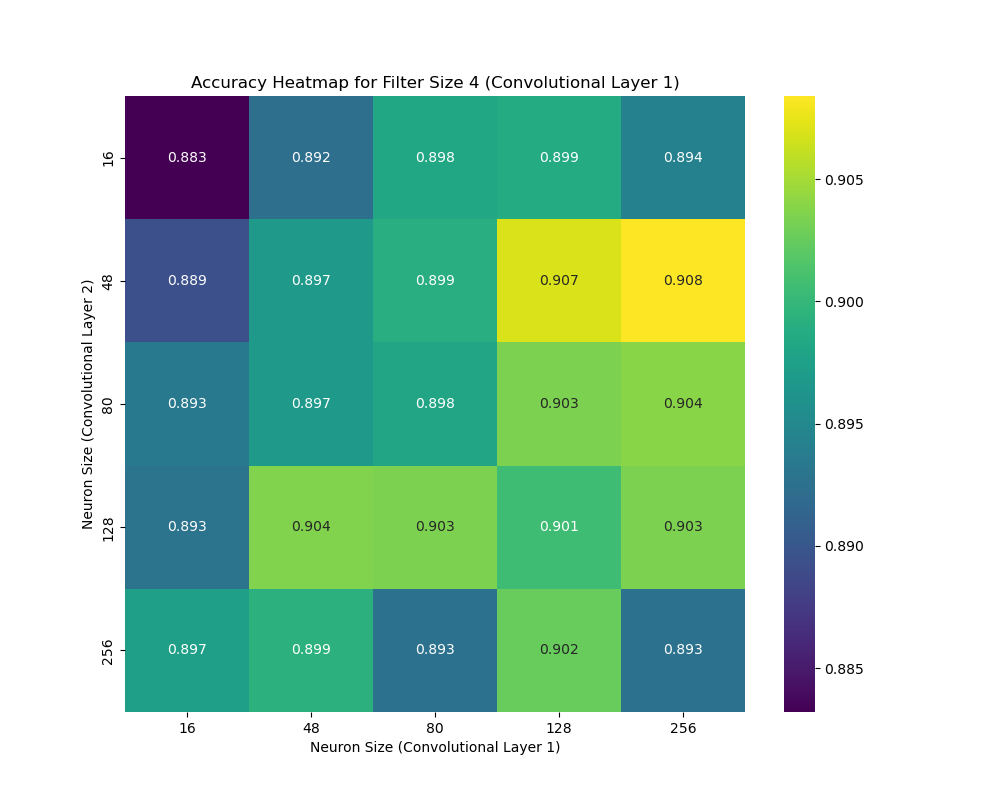

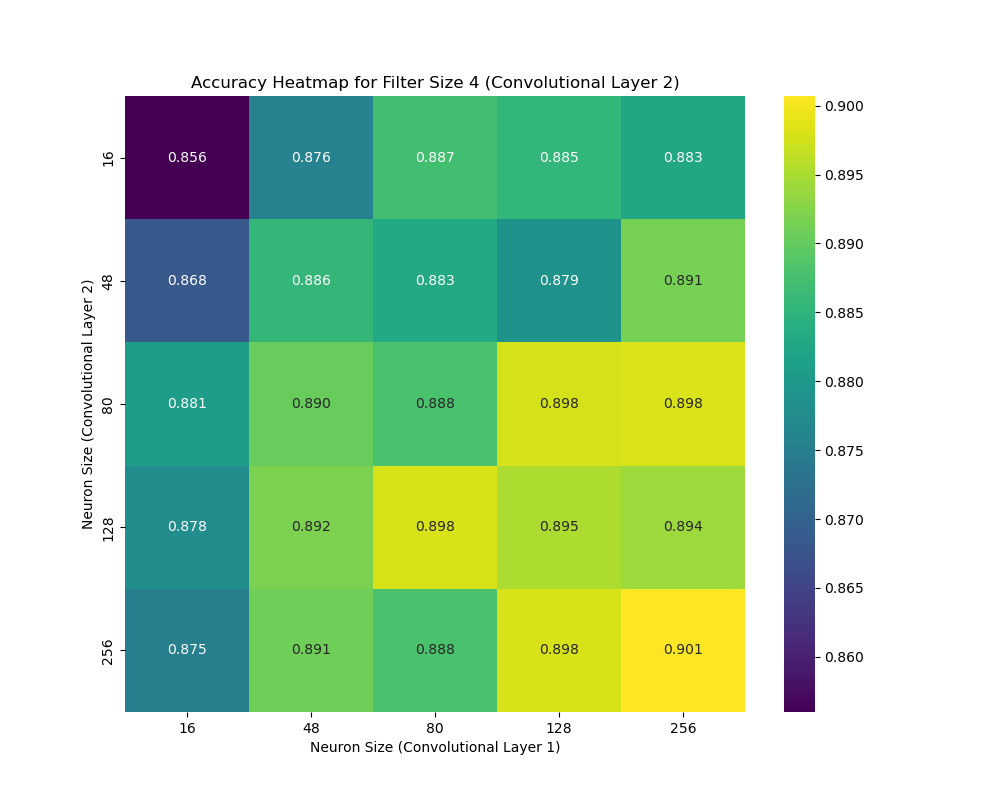

## REFLECTION

## (e) Max-Pooling. 

Update the previous architecture by introducing maxpooling layers after every
convolutional layer. (Use some form of validation to choose the pooling size; justify your choice and discuss the results.)

# INFORMATION:

For neuron numbers [256,256], [48,256] and [256, 48], 

I picked the best pooling sizes and did the heatmap and confusin matrix for the best poolin size. Beow::

In [145]:
import time
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

start_time = time.time()

fixed_filter_sizes = [4, 4]
fixed_neuron_sizes = [256, 256]
pooling_sizes = [(2, 2), (3, 3)]

best_accuracy = 0
best_pooling_size1 = None
best_pooling_size2 = None
best_confusion_matrix = None

accuracy_matrix = np.zeros((len(pooling_sizes), len(pooling_sizes)))

for i, pooling_size1 in enumerate(pooling_sizes):
    for j, pooling_size2 in enumerate(pooling_sizes):
        model_cnn = tf.keras.Sequential([
            tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28, 1)),  # Fix input shape
            tf.keras.layers.Conv2D(fixed_neuron_sizes[0], fixed_filter_sizes[0], activation='relu'),  # First convolutional layer
            tf.keras.layers.MaxPooling2D(pool_size=pooling_size1),  # First max-pooling layer
            tf.keras.layers.Conv2D(fixed_neuron_sizes[1], fixed_filter_sizes[1], activation='relu'),  # Second convolutional layer
            tf.keras.layers.MaxPooling2D(pool_size=pooling_size2),  # Second max-pooling layer
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(10)
        ])

        legacy_adam_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001)
        model_cnn.compile(optimizer=legacy_adam_optimizer,
                          loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                          metrics=['accuracy'])

        model_cnn.fit(X_train.to_numpy().reshape(-1, 28, 28, 1), y_train.to_numpy(), epochs=10,
                      validation_data=(X_val.to_numpy().reshape(-1, 28, 28, 1), y_val.to_numpy()), verbose=0)

        X_test_np = X_test.to_numpy().reshape(-1, 28, 28, 1)

        predictions_cnn = model_cnn.predict(X_test_np)
        predicted_labels_cnn = np.argmax(predictions_cnn, axis=1)

        accuracy_c = accuracy_score(y_test, predicted_labels_cnn)
        accuracy_matrix[i, j] = accuracy_c

        # update the variables
        if accuracy_c > best_accuracy:
            best_accuracy = accuracy_c
            best_pooling_size1 = pooling_size1
            best_pooling_size2 = pooling_size2
            best_confusion_matrix = confusion_matrix(y_test, predicted_labels_cnn)

313/313 [==============================] - 2s 7ms/step


Total Runtime: 47657.008 seconds
Best Pooling Size 1: (3, 3)
Best Pooling Size 2: (3, 3)


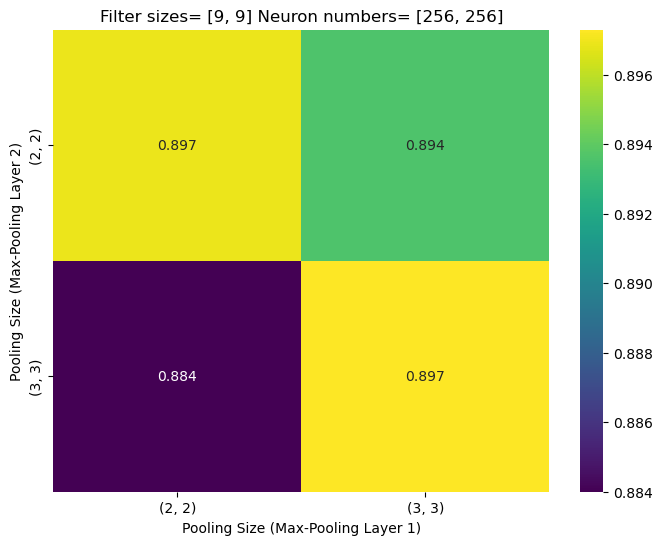

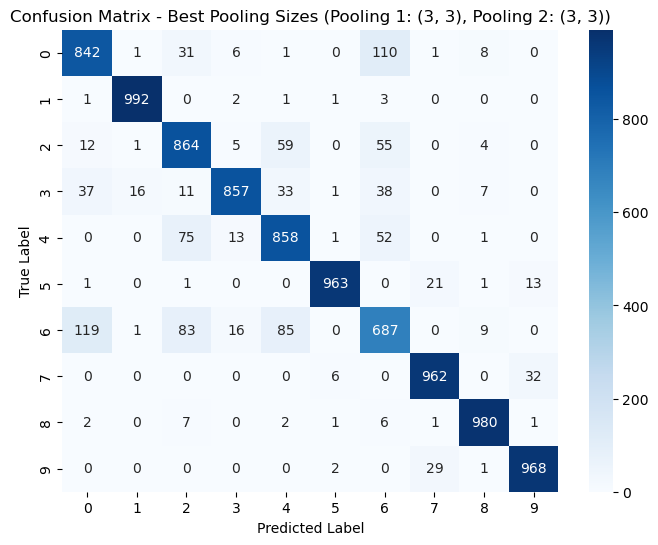

Maximum Accuracy: 0.897
Total Runtime: 47657.008 seconds


In [144]:
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Runtime: {elapsed_time:.3f} seconds")

print(f"Best Pooling Size 1: {best_pooling_size1}")
print(f"Best Pooling Size 2: {best_pooling_size2}")

plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f', cmap='viridis', xticklabels=[f"({size[0]}, {size[1]})" for size in pooling_sizes], yticklabels=[f"({size[0]}, {size[1]})" for size in pooling_sizes])
plt.title("Filter sizes= [9, 9] Neuron numbers= [256, 256]")
plt.xlabel("Pooling Size (Max-Pooling Layer 1)")
plt.ylabel("Pooling Size (Max-Pooling Layer 2)")
plt.show()

if best_confusion_matrix is not None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.title(f"Confusion Matrix - Best Pooling Sizes (Pooling 1: {best_pooling_size1}, Pooling 2: {best_pooling_size2})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

print(f"Maximum Accuracy: {best_accuracy:.3f}")
print(f"Total Runtime: {elapsed_time:.3f} seconds")

Total Runtime: 4922.875 seconds
Best Pooling Size 1: (2, 2)
Best Pooling Size 2: (3, 3)


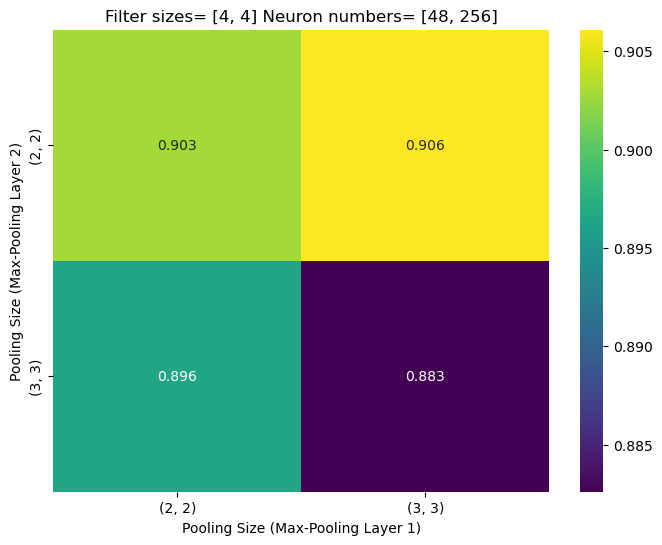

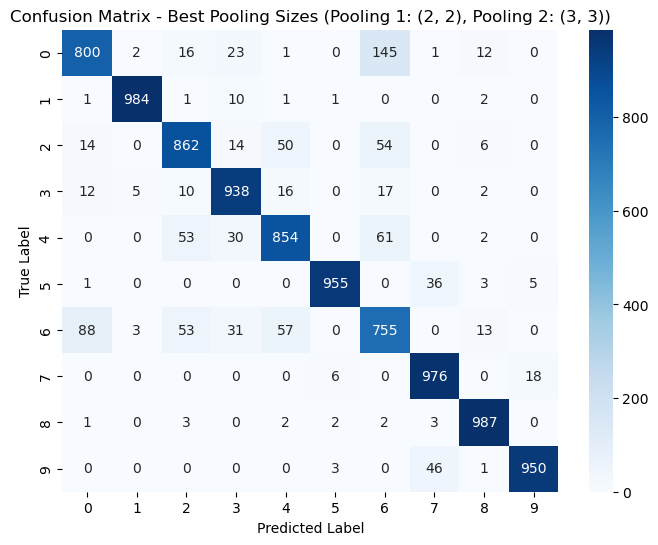

Maximum Accuracy: 0.906
Total Runtime: 4922.875 seconds


In [141]:
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Runtime: {elapsed_time:.3f} seconds")

print(f"Best Pooling Size 1: {best_pooling_size1}")
print(f"Best Pooling Size 2: {best_pooling_size2}")

plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f', cmap='viridis', xticklabels=[f"({size[0]}, {size[1]})" for size in pooling_sizes], yticklabels=[f"({size[0]}, {size[1]})" for size in pooling_sizes])
plt.title("Filter sizes= [4, 4] Neuron numbers= [48, 256]")
plt.xlabel("Pooling Size (Max-Pooling Layer 1)")
plt.ylabel("Pooling Size (Max-Pooling Layer 2)")
plt.show()

if best_confusion_matrix is not None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.title(f"Confusion Matrix - Best Pooling Sizes (Pooling 1: {best_pooling_size1}, Pooling 2: {best_pooling_size2})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

print(f"Maximum Accuracy: {best_accuracy:.3f}")
print(f"Total Runtime: {elapsed_time:.3f} seconds")

Best Pooling Size 1: (2, 2)
Best Pooling Size 2: (2, 2)


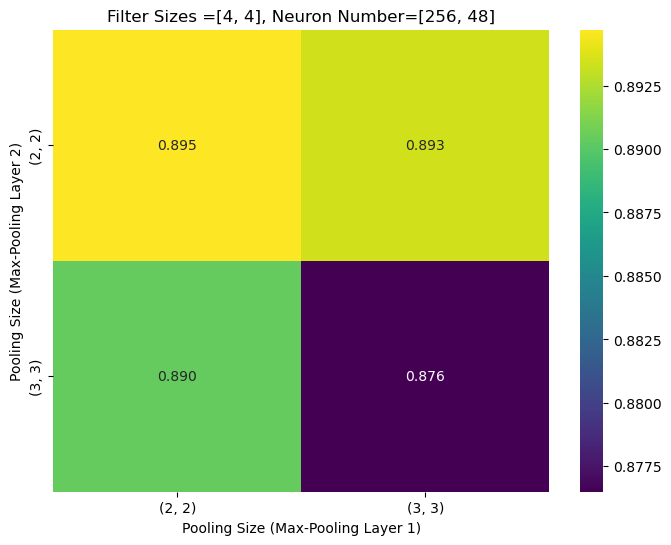

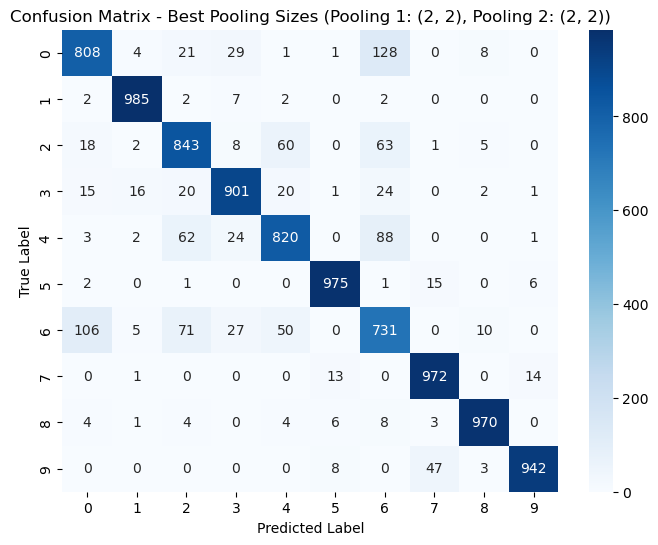

Maximum Accuracy: 0.895
Total Runtime: 17281.223 seconds


In [138]:
print(f"Best Pooling Size 1: {best_pooling_size1}")
print(f"Best Pooling Size 2: {best_pooling_size2}")

plt.figure(figsize=(8, 6))
sns.heatmap(accuracy_matrix, annot=True, fmt='.3f', cmap='viridis', xticklabels=[f"({size[0]}, {size[1]})" for size in pooling_sizes], yticklabels=[f"({size[0]}, {size[1]})" for size in pooling_sizes])
plt.title("Filter Sizes =[4, 4], Neuron Number=[256, 48]")
plt.xlabel("Pooling Size (Max-Pooling Layer 1)")
plt.ylabel("Pooling Size (Max-Pooling Layer 2)")
plt.show()

if best_confusion_matrix is not None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(best_confusion_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.title(f"Confusion Matrix - Best Pooling Sizes (Pooling 1: {best_pooling_size1}, Pooling 2: {best_pooling_size2})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

print(f"Maximum Accuracy: {best_accuracy:.3f}")
print(f"Total Runtime: {elapsed_time:.3f} seconds")


# REFLECTION

Best pooling size was:

Best Pooling Size 1: (2, 2)
Best Pooling Size 2: (3, 3)

with the accuracy of 0.906

## (f) Accuracy & Runtime. 

Compare and contrast the models in parts (b) - (e) in terms of test accuracy.

Report the confusion matrix for classifying to the di erent classes. Which approach is best? Why?

What type of architectural changes might you make to further improve the accuracy? 

Also report the training time required for each of the above models. Which is the best computationally relative to its accuracy?

## Accuracy

Accuracies:

b) Feedforward neural network with a single hidden layer:0.854

c) Feedforward neural network with 2 hidden layers:0.867

d) Network with 2 convolutional layers: 0.908

e) Network with maxpooling layers after every convolutional layer:0.907


In (b) for the model with one hidden layer, the best accuracy was 0.854 when I fine tuned for learning rate and neuron number. 

In (c) for the model with two hidden layer, the best accuracy was 0.867 when I only fine tuned for the neuron number for two layers. 

In terms of accuracy, adding pool (e) did not chnage the best accuracy that I got by  the model with two convultaional layers (d), which was 0.908.

That might be because I fine tuned for the filter size while also tuning for the neuron sizes. I think that is essential to do so. Because for different neuron sizes best filter size seems to differ too. 

## Confusion matrix: 
Looking at the confusion matrixes, printed above, mostly confused image was the shirt. Mostly, it was either confused with a pullower, t-shirt or a coat. The classification was better for the convulational models (d) and when pool added (e). 


I would try with two hidden and two convulational layers. 

As far as I see from the practices, fine tuning is also as critical as the layer number and the architecture, although it takes to long for several looping. 


I would fine tune for the neuron number, learning rate, pooling number and filter all at once and get the best parameters. 


# Time

The training time was the longest for me for (d) Network with 2 convolutional layers, taking over 33 hours. 
 
For pooling I did not fine ti=uned again for the neuron numbers, but also fine tuned for pooling sizes it took 1.5 hours to 13 hours depending on the neuron sizes in the two layers. If I added the fine tuning for the neuron sizes that would take a couple of days. 

One layer and two layer feed forward networks were much shorter. Took couple of minutes for each run. But if I made the loop as I wanted, it would run for longer time. It depends on the number of loops, and neuron number.  

Running time depends on heavily to network sizes and number of parameters that we tune for.Depending on my results, I would pick Network with 2 convolutional layers: 0.908. That took over a day but at least the run was completed. I wouldn't mind waiting, since the accuracy passed 0.9. 

# 
For the reference of the label names:

label_names = {

    0: "T-shirt/top",
    
    1: "Trouser",
    
    2: "Pullover",
    
    3: "Dress",
    
    4: "Coat",
    
    5: "Sandal",
    
    6: "Shirt",
    
    7: "Sneaker",
    
    8: "Bag",
    
    9: "Ankle boot"}

# Applied 2

## Tree-Based Methods. 

This problem will use the Adult Dataset available from https://archive.ics.
uci.edu/ml/datasets/adult. The dataset is already split into a training and test set and you should report accuracy results on this test set.

In [266]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

adult_test = pd.read_csv("adult.test.csv")
adult_train= pd.read_csv("adult.data.csv")

In [267]:
X_train1 = adult_train.drop('salary', axis=1)
y_train = adult_train['salary']

X_test1 = adult_test.drop('salary', axis=1)
y_test = adult_test['salary']



In [268]:
from sklearn.impute import SimpleImputer

# Assuming 'X_encoded' is your DataFrame containing the one-hot encoded features
# If not, replace 'X_encoded' with the actual variable containing your features

# Columns to impute
columns_to_impute = ['native-country', 'occupation', 'workclass']

# Initialize SimpleImputer with strategy='most_frequent'
imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform the selected columns
X_train1[columns_to_impute] = imputer.fit_transform(X_train1[columns_to_impute])
X_test1[columns_to_impute] = imputer.fit_transform(X_test1[columns_to_impute])

# Display the resulting DataFrame with missing values replaced
print(X_test1.head())


   age   workclass  fnlwgt      education  education-num       marital-status  \
0   25     Private  226802           11th              7        Never-married   
1   38     Private   89814        HS-grad              9   Married-civ-spouse   
2   28   Local-gov  336951     Assoc-acdm             12   Married-civ-spouse   
3   44     Private  160323   Some-college             10   Married-civ-spouse   
4   18           ?  103497   Some-college             10        Never-married   

           occupation relationship    race      sex  capital-gain  \
0   Machine-op-inspct    Own-child   Black     Male             0   
1     Farming-fishing      Husband   White     Male             0   
2     Protective-serv      Husband   White     Male             0   
3   Machine-op-inspct      Husband   Black     Male          7688   
4                   ?    Own-child   White   Female             0   

   capital-loss  hours-per-week  native-country  
0             0              40   United-States 

In [269]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Assuming 'X' is your features DataFrame
# If not, you should replace 'X' with the actual variable containing your features

# Extracting categorical columns
categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Creating a new DataFrame with only the categorical columns
categorical_df = X_train1[categorical_columns]

# Initializing the OneHotEncoder
encoder = OneHotEncoder(sparse=False, drop='first')

# Fit and transform the categorical columns
encoded_data = encoder.fit_transform(categorical_df)

# Creating a DataFrame with the one-hot encoded data
one_hot_encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenating the one-hot encoded DataFrame with the original features DataFrame
X_train = pd.concat([X_train1, one_hot_encoded_df], axis=1)

# Dropping the original categorical columns from the DataFrame
X_train = X_train.drop(categorical_columns, axis=1)

# Display the resulting DataFrame with one-hot encoded columns
print(X_train.head())


   age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   workclass_ Federal-gov  workclass_ Local-gov  workclass_ Never-worked  \
0                     0.0                   0.0                      0.0   
1                     0.0                   0.0                      0.0   
2                     0.0                   0.0                      0.0   
3                     0.0                   0.0                      0.0   
4                     0.0                   0.0                      0.0   

   workclass_ Private  ...  native-country_ Portugal  \
0                 0.0  .

/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [270]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Assuming 'X' is your features DataFrame
# If not, you should replace 'X' with the actual variable containing your features

# Extracting categorical columns
categorical_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Creating a new DataFrame with only the categorical columns
categorical_df = X_test1[categorical_columns]

# Initializing the OneHotEncoder
encoder = OneHotEncoder(sparse=False, drop='first')

# Fit and transform the categorical columns
encoded_data = encoder.fit_transform(categorical_df)

# Creating a DataFrame with the one-hot encoded data
one_hot_encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns))

# Concatenating the one-hot encoded DataFrame with the original features DataFrame
X_test = pd.concat([X_test1, one_hot_encoded_df], axis=1)

# Dropping the original categorical columns from the DataFrame
X_test = X_test.drop(categorical_columns, axis=1)

# Display the resulting DataFrame with one-hot encoded columns
print(X_test.head())


   age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week  \
0   25  226802              7             0             0              40   
1   38   89814              9             0             0              50   
2   28  336951             12             0             0              40   
3   44  160323             10          7688             0              40   
4   18  103497             10             0             0              30   

   workclass_ Federal-gov  workclass_ Local-gov  workclass_ Never-worked  \
0                     0.0                   0.0                      0.0   
1                     0.0                   0.0                      0.0   
2                     0.0                   1.0                      0.0   
3                     0.0                   0.0                      0.0   
4                     0.0                   0.0                      0.0   

   workclass_ Private  ...  native-country_ Portugal  \
0                 1.0  .

/Users/taksoy/anaconda3/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [271]:
# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32561, 100)
X_test shape: (16281, 99)
y_train shape: (32561,)
y_test shape: (16281,)


In [272]:
# Convert feature names to strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)



In [273]:
# Find the extra column in X_train
extra_column_in_X_train = set(X_train.columns) - set(X_test.columns)
print("Extra column in X_train:", extra_column_in_X_train)

# Find the extra column in X_test
extra_column_in_X_test = set(X_test.columns) - set(X_train.columns)
print("Extra column in X_test:", extra_column_in_X_test)


Extra column in X_train: {'native-country_ Holand-Netherlands'}
Extra column in X_test: set()


In [274]:
# Add a placeholder column for the missing category in X_test
X_test['native-country_ Holand-Netherlands'] = 0


In [275]:
# Get the columns order from X_train
column_order = X_train.columns

# Reorder columns in X_test
X_test = X_test[column_order]


## (a) Loss Functions. 
Compare and contrast trees, bagging, and Random Forests using the Gini index
verses the cross entropy loss. Which performs better? Why?

## Decision tree

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score


# Gini index
tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_gini.fit(X_train, y_train)

y_pred_tree_gini = tree_gini.predict(X_test)

accuracy_tree_gini = accuracy_score(y_test, y_pred_tree_gini)
print("Decision Tree with Gini Index Accuracy: {:.2f}%".format(accuracy_tree_gini * 100))


# cross-entropy loss
tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_entropy.fit(X_train, y_train)

y_pred_tree_entropy = tree_entropy.predict(X_test)

accuracy_tree_entropy = accuracy_score(y_test, y_pred_tree_entropy)
print("Decision Tree with Cross-Entropy Loss Accuracy: {:.2f}%".format(accuracy_tree_entropy * 100))



Decision Tree with Gini Index Accuracy: 81.15%
Decision Tree with Cross-Entropy Loss Accuracy: 81.62%


## Bagging

In [15]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Gini 
bagging_gini = BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini', random_state=42), random_state=42)
bagging_gini.fit(X_train, y_train)

y_pred_bagging_gini = bagging_gini.predict(X_test)

accuracy_bagging_gini = accuracy_score(y_test, y_pred_bagging_gini)
print("Bagging with Gini Index Accuracy: {:.2f}%".format(accuracy_bagging_gini * 100))

#Cross-Entropy 
bagging_entropy = BaggingClassifier(estimator=DecisionTreeClassifier(criterion='entropy', random_state=42), random_state=42)
bagging_entropy.fit(X_train, y_train)

y_pred_bagging_entropy = bagging_entropy.predict(X_test)

accuracy_bagging_entropy = accuracy_score(y_test, y_pred_bagging_entropy)
print("Bagging with Cross-Entropy Loss Accuracy: {:.2f}%".format(accuracy_bagging_entropy * 100))

Bagging with Gini Index Accuracy: 84.56%
Bagging with Cross-Entropy Loss Accuracy: 84.97%


## Random Forest

In [18]:
#  Gini index
random_forest = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
random_forest.fit(X_train, y_train.values.ravel())

y_pred_random_forest = random_forest.predict(X_test)

accuracy_random_forest_gini = accuracy_score(y_test, y_pred_random_forest)
print("Random Forest Accuracy: {:.2f}%".format(accuracy_random_forest_gini * 100))


#  cross-entropy 
random_forest_entropy = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
random_forest_entropy.fit(X_train, y_train.values.ravel())

y_pred_random_forest_entropy = random_forest_entropy.predict(X_test)

accuracy_random_forest_entropy = accuracy_score(y_test, y_pred_random_forest_entropy)
print("Random Forest with Cross-Entropy Loss Accuracy: {:.2f}%".format(accuracy_random_forest_entropy * 100))


Random Forest Accuracy: 85.27%
Random Forest with Cross-Entropy Loss Accuracy: 85.27%


In [19]:
import pandas as pd

# Define the data
data = {
    'Model': ['Decision Tree (Gini)', 'Decision Tree (Entropy)', 'Bagging (Gini)', 'Bagging (Entropy)', 'Random Forest (Gini)', 'Random Forest (Entropy)'],
    'Accuracy': [accuracy_tree_gini, accuracy_tree_entropy, accuracy_bagging_gini, accuracy_bagging_entropy, accuracy_random_forest_gini, accuracy_random_forest_entropy]
}

# Create a DataFrame
accuracy_table = pd.DataFrame(data)

# Display the table
print(accuracy_table)


                     Model  Accuracy
0     Decision Tree (Gini)  0.811498
1  Decision Tree (Entropy)  0.816166
2           Bagging (Gini)  0.845587
3        Bagging (Entropy)  0.849702
4     Random Forest (Gini)  0.852712
5  Random Forest (Entropy)  0.852712


## REFLECTION

SUMMARY:

                     
Decision Tree (Gini)  0.811498

Decision Tree (Entropy)  0.816166

Bagging (Gini)  0.845587

Bagging (Entropy)  0.849702

Random Forest (Gini)  0.852712

Random Forest (Entropy)  0.852712


All models exceed 0.8 accuracy while Random forest with Gini and Entrpy both performs better than Decision tree and Bagging models. Random forest actually is very close to Bagging.

Decision Tree models serve as the base models for bagging and Random Forests while bagging model provides some improvement probably with ensamble. Random forest might be adding some randomness during tree constraction that possibly improve the accuracy. 

## (b) Out of Bag Error

For Bagging and Random Forests, plot the out of bag error verses the number of trees in the ensemble. How does the out of bag error compare to that of the test error?

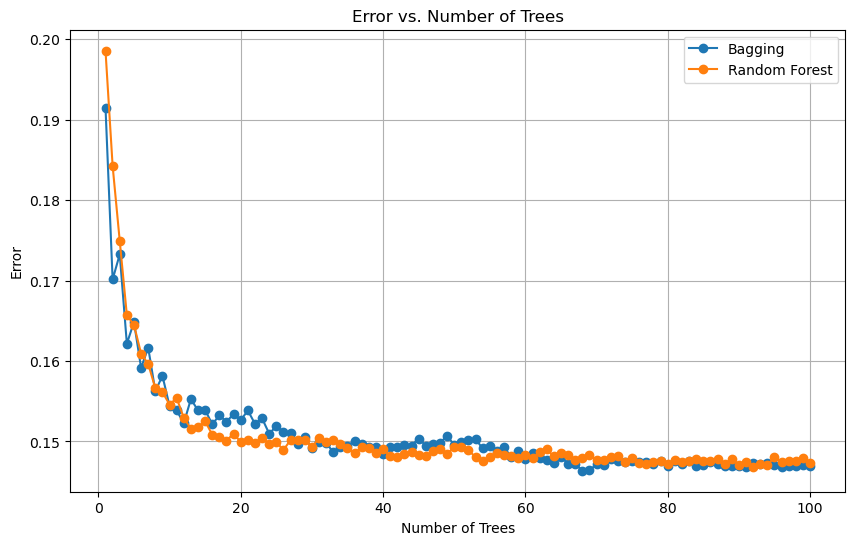

In [22]:
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Bagging
bagging_errors = []
bagging_n_estimators = range(1, 101)  

for n in bagging_n_estimators:
    model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=n, oob_score=False, random_state=42)
    model.fit(X_train, y_train.values.ravel())  # Use .values.ravel() to flatten y
    bagging_errors.append(1 - model.score(X_test, y_test))

# Random Forests
rf_errors = []
rf_n_estimators = range(1, 101) 

for n in rf_n_estimators:
    model = RandomForestClassifier(n_estimators=n, oob_score=False, random_state=42)
    model.fit(X_train, y_train.values.ravel())  # Use .values.ravel() to flatten y
    rf_errors.append(1 - model.score(X_test, y_test))

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(bagging_n_estimators, bagging_errors, label='Bagging', marker='o')
plt.plot(rf_n_estimators, rf_errors, label='Random Forest', marker='o')

plt.title('Error vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()


## (c) Hyperparameters

Try to purposefully overfit each of the following approaches: trees, bagging,
AdaBoost, Gradient Boosting, and Random Forests. Were you able to overfit? 

What hyperparameters did you use to overfit these approaches? 

Plot the training and test error as a function of some of the hyperparameters for various approaches to show which hyperparameters can lead to overfitting. 

You may want to try varying the tree size, number of iterations (Boosting) learning
rate (Boosting), and/or the number of features to consider for each split (Random Forests).

## 1- Decision Trees:

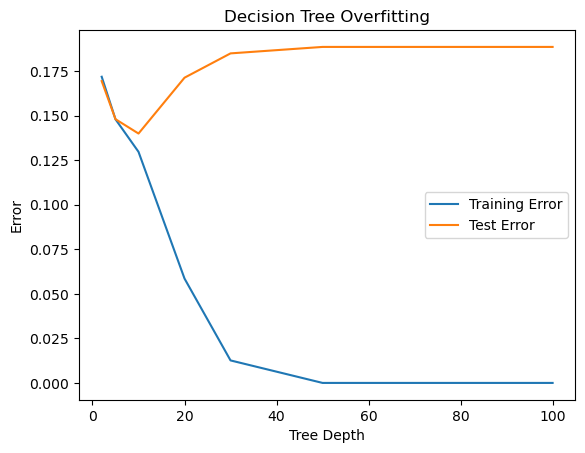

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
import matplotlib.pyplot as plt


# Vary the maximum depth of the tree
tree_depths = [2, 5, 10, 20, 30, 50, 100]
train_errors = []
test_errors = []

for depth in tree_depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_errors.append(1 - tree.score(X_train, y_train))
    test_errors.append(1 - tree.score(X_test, y_test))

plt.plot(tree_depths, train_errors, label='Training Error')
plt.plot(tree_depths, test_errors, label='Test Error')
plt.xlabel('Tree Depth')
plt.ylabel('Error')
plt.title('Decision Tree Overfitting')
plt.legend()
plt.show()


## 2- Bagging

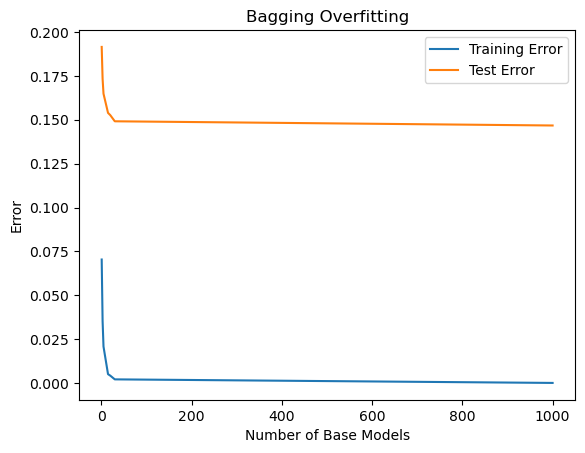

In [35]:
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Increased the number of base estimators 
n_estimators_values = [ 1, 3, 5, 15, 20, 30, 1000]
train_errors = []
test_errors = []

for n_estimators in n_estimators_values:

    bagging = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None),
                                n_estimators=n_estimators, random_state=42)
    bagging.fit(X_train, y_train.values.ravel())  
    train_errors.append(1 - bagging.score(X_train, y_train))
    test_errors.append(1 - bagging.score(X_test, y_test))


plt.plot(n_estimators_values, train_errors, label='Training Error')
plt.plot(n_estimators_values, test_errors, label='Test Error')
plt.xlabel('Number of Base Models')
plt.ylabel('Error')
plt.title('Bagging Overfitting')
plt.legend()
plt.show()


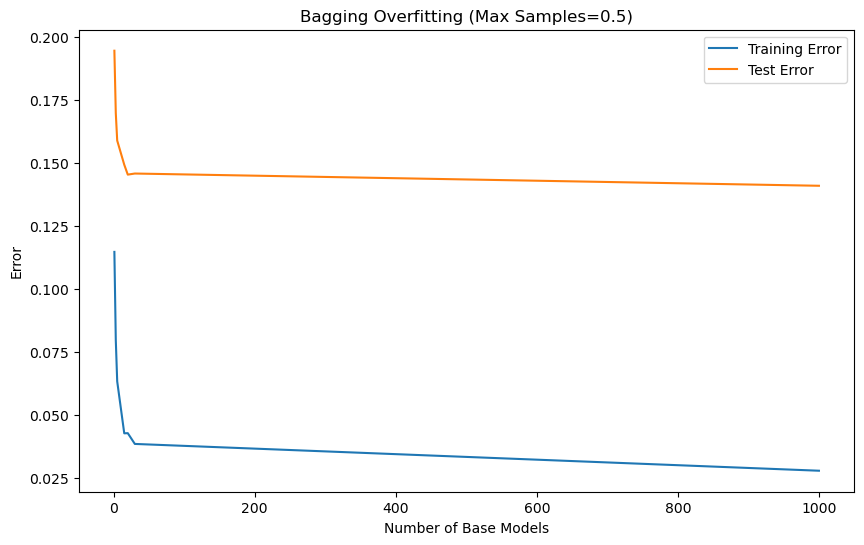

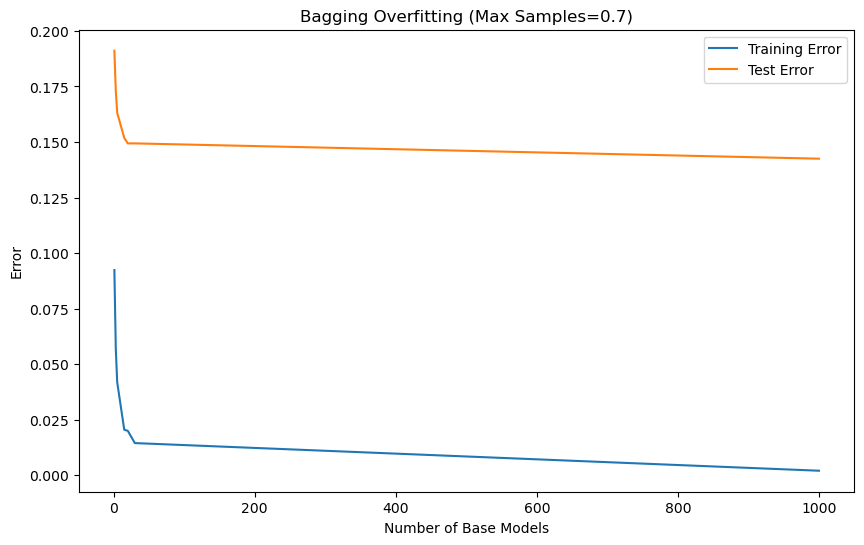

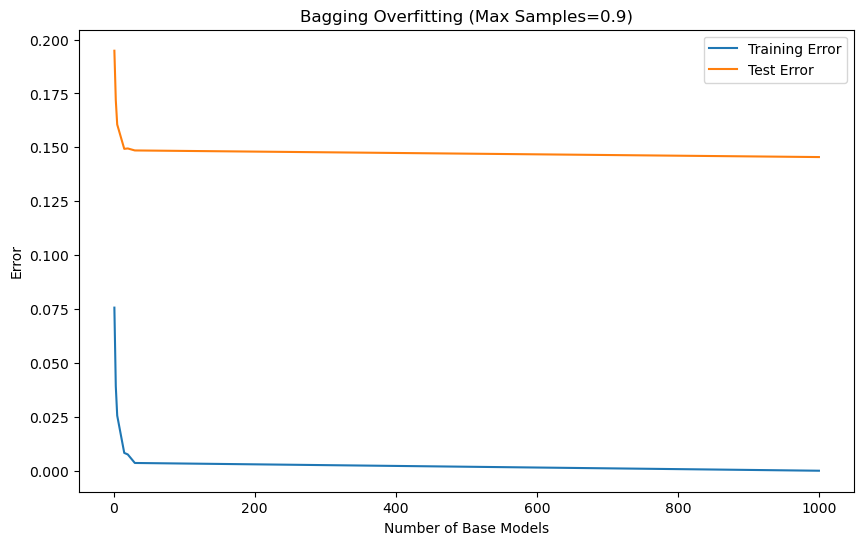

In [49]:
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Values to experiment with
n_estimators_values = [1, 3, 5, 15, 20, 30, 1000]
max_samples_values = [0.5, 0.7, 0.9]  # Bootstrap Sampling

for max_samples in max_samples_values:
    train_errors = []
    test_errors = []

    for n_estimators in n_estimators_values:
        bagging = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=None),
            n_estimators=n_estimators,
            max_samples=max_samples,
            random_state=42
        )
        bagging.fit(X_train, y_train.values.ravel())
        train_errors.append(1 - bagging.score(X_train, y_train))
        test_errors.append(1 - bagging.score(X_test, y_test))

    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_values, train_errors, label='Training Error')
    plt.plot(n_estimators_values, test_errors, label='Test Error')
    plt.xlabel('Number of Base Models')
    plt.ylabel('Error')
    plt.title(f'Bagging Overfitting (Max Samples={max_samples})')
    plt.legend()
    plt.show()


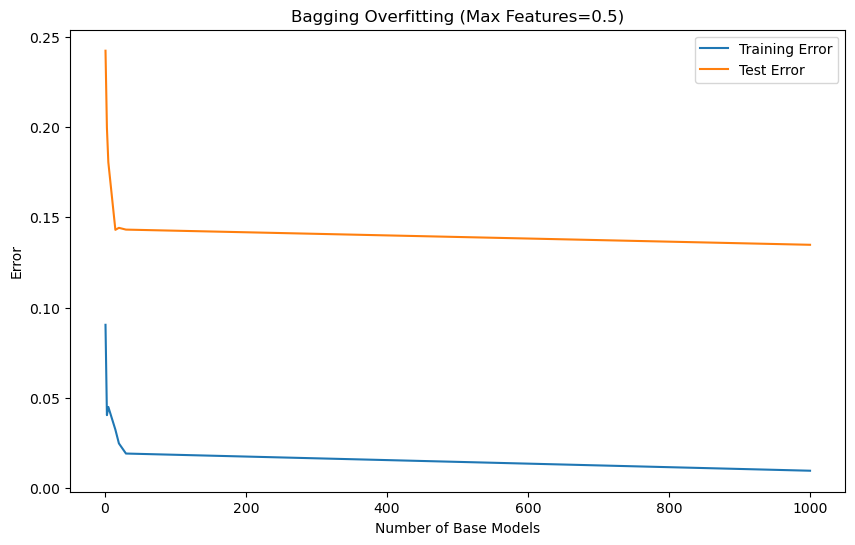

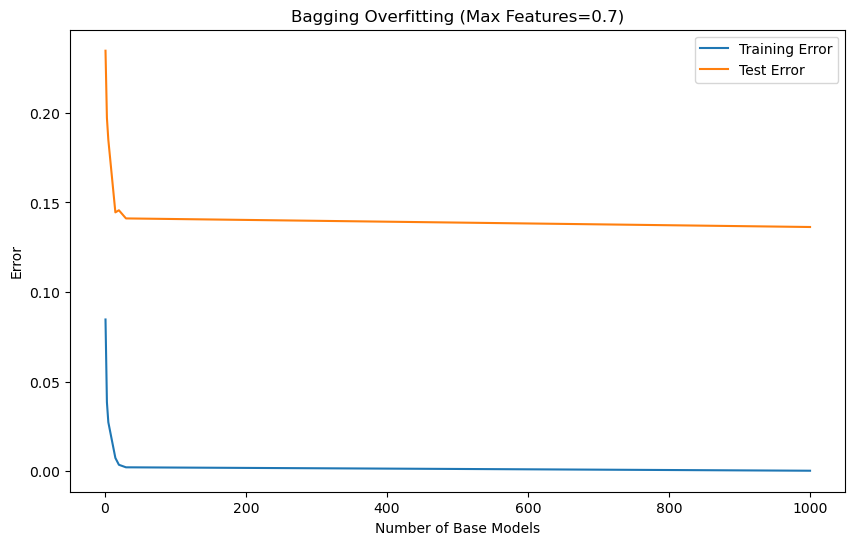

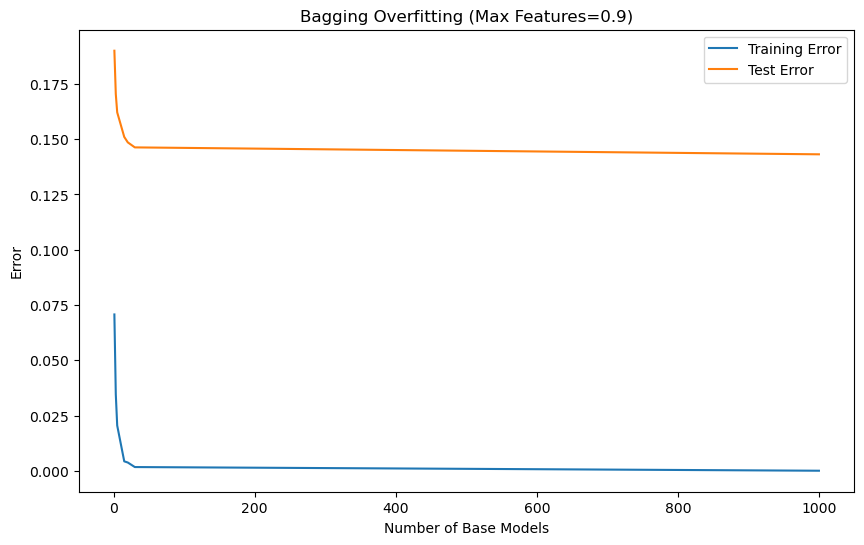

In [50]:
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Values to experiment with
n_estimators_values = [1, 3, 5, 15, 20, 30, 1000]
max_features_values = [0.5, 0.7, 0.9]  # Feature Sampling

for max_features in max_features_values:
    train_errors = []
    test_errors = []

    for n_estimators in n_estimators_values:
        bagging = BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=None),
            n_estimators=n_estimators,
            max_features=max_features,
            random_state=42
        )
        bagging.fit(X_train, y_train.values.ravel())
        train_errors.append(1 - bagging.score(X_train, y_train))
        test_errors.append(1 - bagging.score(X_test, y_test))

    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_values, train_errors, label='Training Error')
    plt.plot(n_estimators_values, test_errors, label='Test Error')
    plt.xlabel('Number of Base Models')
    plt.ylabel('Error')
    plt.title(f'Bagging Overfitting (Max Features={max_features})')
    plt.legend()
    plt.show()


## 3- AdaBoost

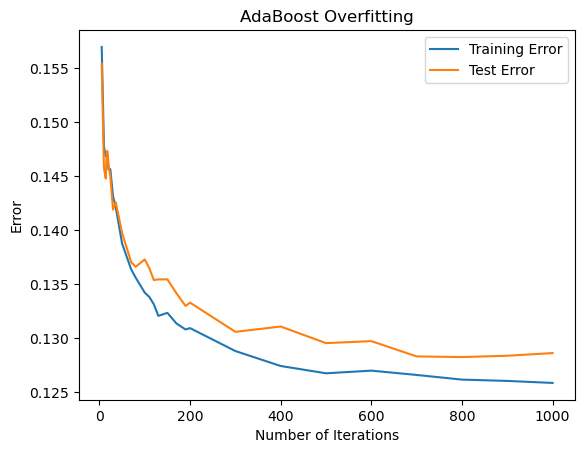

In [36]:
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Increased the number of iterations
n_iterations_values = [5, 10, 12, 14, 16, 18, 20, 24, 30, 36, 50, 70, 80, 100, 110, 120, 130, 150, 170, 190, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
train_errors = []
test_errors = []

for n_iterations in n_iterations_values:
    adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                  n_estimators=n_iterations, random_state=42)
    adaboost.fit(X_train, y_train.values.ravel())  
    train_errors.append(1 - adaboost.score(X_train, y_train))
    test_errors.append(1 - adaboost.score(X_test, y_test))

plt.plot(n_iterations_values, train_errors, label='Training Error')
plt.plot(n_iterations_values, test_errors, label='Test Error')
plt.xlabel('Number of Iterations')
plt.ylabel('Error')
plt.title('AdaBoost Overfitting')
plt.legend()
plt.show()


## 4- Gradient Boosting:

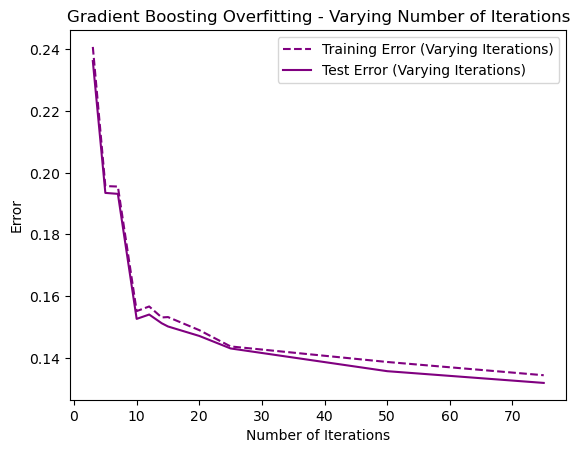

In [40]:
# increse the number of iterations
n_iterations_values = [3, 5, 7, 10, 12, 14, 15, 20, 25, 50, 75]
train_errors_iterations = []
test_errors_iterations = []

for n_iterations in n_iterations_values:
    gradient_boosting = GradientBoostingClassifier(n_estimators=n_iterations, learning_rate=0.1, random_state=42)
    gradient_boosting.fit(X_train, y_train.values.ravel()) 
    train_errors_iterations.append(1 - gradient_boosting.score(X_train, y_train))
    test_errors_iterations.append(1 - gradient_boosting.score(X_test, y_test))

plt.plot(n_iterations_values, train_errors_iterations, '--', color='purple', label='Training Error (Varying Iterations)')
plt.plot(n_iterations_values, test_errors_iterations, '-', color='purple', label='Test Error (Varying Iterations)')

plt.xlabel('Number of Iterations')
plt.ylabel('Error')
plt.title('Gradient Boosting Overfitting - Varying Number of Iterations')
plt.legend()
plt.show()


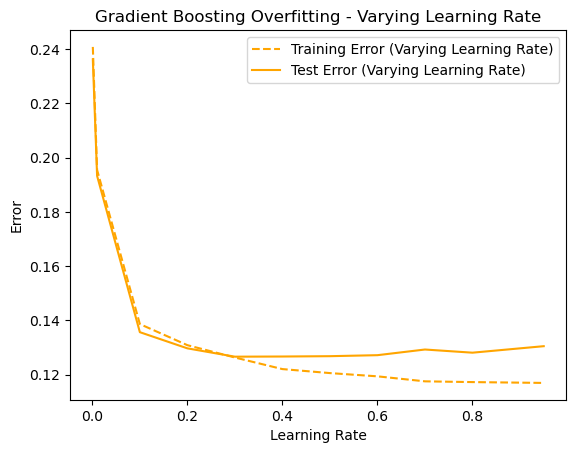

In [38]:
# Vary the learning rate
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.95]
train_errors_lr = []
test_errors_lr = []

for rate in learning_rates:
    gradient_boosting = GradientBoostingClassifier(n_estimators=50, learning_rate=rate, random_state=42)
    gradient_boosting.fit(X_train, y_train.values.ravel()) 
    train_errors_lr.append(1 - gradient_boosting.score(X_train, y_train))
    test_errors_lr.append(1 - gradient_boosting.score(X_test, y_test))

plt.plot(learning_rates, train_errors_lr, '--', color='orange', label='Training Error (Varying Learning Rate)')
plt.plot(learning_rates, test_errors_lr, '-', color='orange', label='Test Error (Varying Learning Rate)')

plt.xlabel('Learning Rate')
plt.ylabel('Error')
plt.title('Gradient Boosting Overfitting - Varying Learning Rate')
plt.legend()
plt.show()


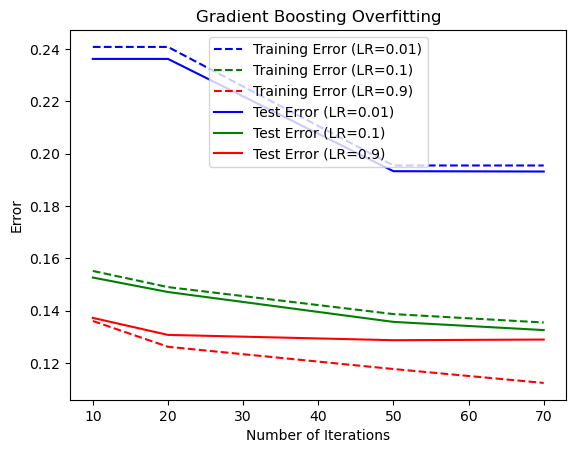

In [44]:
# change number of iterations and learning rate
n_iterations_values = [10, 20, 50, 70]
learning_rates = [0.01, 0.1, 0.9]
train_errors = {}
test_errors = {}

for rate in learning_rates:
    train_errors[rate] = []
    test_errors[rate] = []
    for n_iterations in n_iterations_values:
        gradient_boosting = GradientBoostingClassifier(n_estimators=n_iterations,
                                                       learning_rate=rate, random_state=42)
        gradient_boosting.fit(X_train, y_train.values.ravel())  
        train_errors[rate].append(1 - gradient_boosting.score(X_train, y_train))
        test_errors[rate].append(1 - gradient_boosting.score(X_test, y_test))

colors = ['blue', 'green', 'red']

for i, (rate, errors) in enumerate(train_errors.items()):
    plt.plot(n_iterations_values, errors, '--', label=f'Training Error (LR={rate})', color=colors[i])
for i, (rate, errors) in enumerate(test_errors.items()):
    plt.plot(n_iterations_values, errors, '-', label=f'Test Error (LR={rate})', color=colors[i])

plt.xlabel('Number of Iterations')
plt.ylabel('Error')
plt.title('Gradient Boosting Overfitting')
plt.legend()
plt.show()


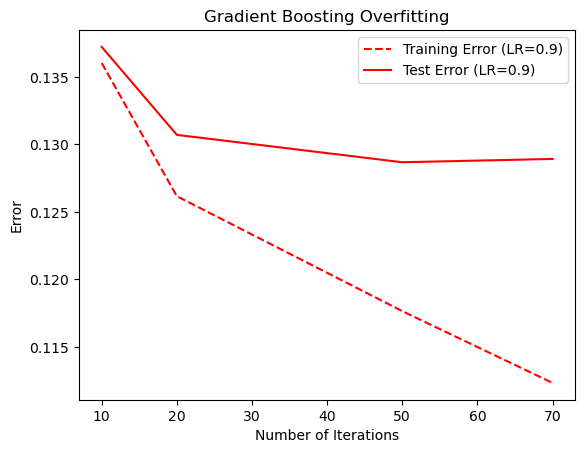

In [48]:
# change number of iterations and learning rate
n_iterations_values = [10, 20, 50, 70]
learning_rates = [0.9]
train_errors = {}
test_errors = {}

for rate in learning_rates:
    train_errors[rate] = []
    test_errors[rate] = []
    for n_iterations in n_iterations_values:
        gradient_boosting = GradientBoostingClassifier(n_estimators=n_iterations,
                                                       learning_rate=rate, random_state=42)
        gradient_boosting.fit(X_train, y_train.values.ravel()) 
        train_errors[rate].append(1 - gradient_boosting.score(X_train, y_train))
        test_errors[rate].append(1 - gradient_boosting.score(X_test, y_test))

colors = [ 'red']

for i, (rate, errors) in enumerate(train_errors.items()):
    plt.plot(n_iterations_values, errors, '--', label=f'Training Error (LR={rate})', color=colors[i])
for i, (rate, errors) in enumerate(test_errors.items()):
    plt.plot(n_iterations_values, errors, '-', label=f'Test Error (LR={rate})', color=colors[i])

plt.xlabel('Number of Iterations')
plt.ylabel('Error')
plt.title('Gradient Boosting Overfitting')
plt.legend()
plt.show()


## 5- Random Forests:

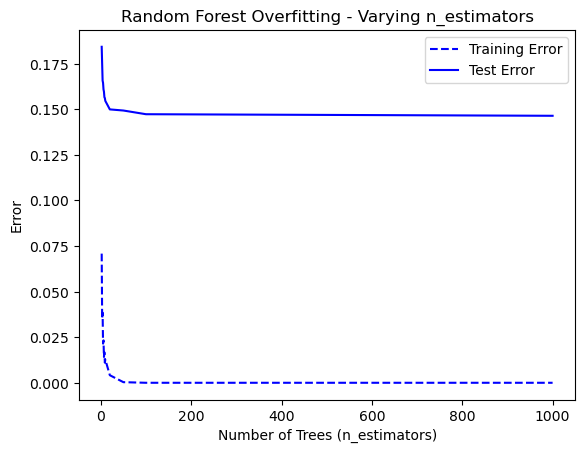

In [46]:
# increased the number of trees (n_estimators)
n_trees_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50, 100, 1000]
train_errors_n_trees = []
test_errors_n_trees = []

for n_trees in n_trees_values:
    random_forest = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    random_forest.fit(X_train, y_train.values.ravel()) 
    train_errors_n_trees.append(1 - random_forest.score(X_train, y_train))
    test_errors_n_trees.append(1 - random_forest.score(X_test, y_test))

plt.plot(n_trees_values, train_errors_n_trees,  '--', color= 'blue', label='Training Error')
plt.plot(n_trees_values, test_errors_n_trees, '-', color= 'blue', label='Test Error')

plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Error')
plt.title('Random Forest Overfitting - Varying n_estimators')
plt.legend()
plt.show()


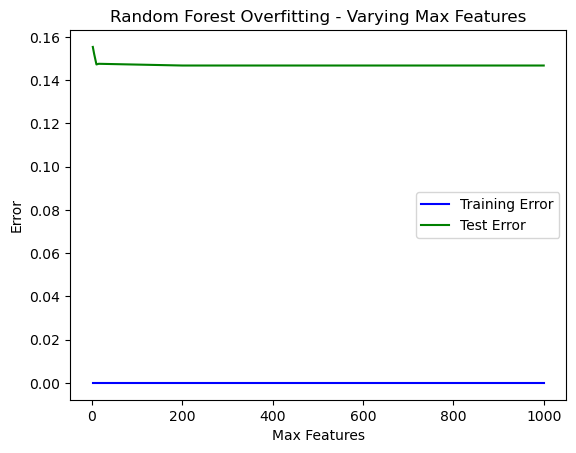

In [47]:
#  Increased the maximum number of features (max_features)
max_features_values = [2, 5, 10, 15, 200, 500, 1000]
train_errors_max_features = []
test_errors_max_features = []

for feature in max_features_values:
    random_forest = RandomForestClassifier(max_features=feature, random_state=42)
    random_forest.fit(X_train, y_train.values.ravel()) 
    train_errors_max_features.append(1 - random_forest.score(X_train, y_train))
    test_errors_max_features.append(1 - random_forest.score(X_test, y_test))

plt.plot(max_features_values, train_errors_max_features, color= 'blue',  label='Training Error')
plt.plot(max_features_values, test_errors_max_features, color= 'green', label='Test Error')

plt.xlabel('Max Features')
plt.ylabel('Error')
plt.title('Random Forest Overfitting - Varying Max Features')
plt.legend()
plt.show()


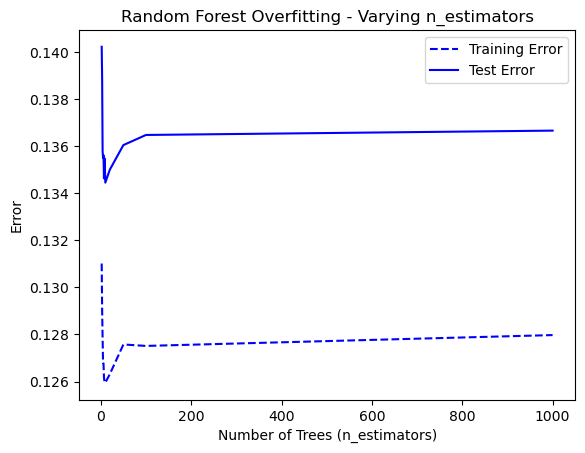

In [53]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Assume X_train, X_test, y_train, y_test are your training and test sets
# Adjust the hyperparameters based on your specific case

# Hyperparameters to adjust
n_trees_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 50, 100, 1000]
train_errors_n_trees = []
test_errors_n_trees = []

# Adjusted Random Forest with specific hyperparameters
random_forest = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,             # Set a maximum depth 
    min_samples_split=5,      # Increase the minimum samples for splitting
    min_samples_leaf=2,       # Increase the minimum samples per leaf
    max_features=0.8,         # Control the number of features considered for each split
    random_state=42
)

for n_trees in n_trees_values:
    random_forest.n_estimators = n_trees
    random_forest.fit(X_train, y_train.values.ravel()) 
    train_errors_n_trees.append(1 - random_forest.score(X_train, y_train))
    test_errors_n_trees.append(1 - random_forest.score(X_test, y_test))

# Plotting
plt.plot(n_trees_values, train_errors_n_trees, '--', color='blue', label='Training Error')
plt.plot(n_trees_values, test_errors_n_trees, '-', color='blue', label='Test Error')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Error')
plt.title('Random Forest Overfitting - Varying n_estimators')
plt.legend()
plt.show()


## REFLECTION:

### 1- Decision trees:

I increased the number of tree depth from 2 to 100. Overfitting was visible as early as 10 iterations. After 50 iterations, the test and train errors converged to ~0.180 and 0.0001, respectively. 

### 2- Bagging:

I increased the number of base estimators. the test and train errors were ~0.185 and ~0.075 for esti,ator= 1. For increased estimator value, test error converged to 0.15 while train error converged to 0.0001. 

I then tried tuning for max sampling and max features, but they did not contribute to the overfitting. 


### 3- Adaboost:

I increased the number of iterations that led to slight difference in accuracy for increased iterations. Train error converged to 0.125 and test error converged to 0.13.This doesn't seem like a singificant difference. 


### 4- Gradient Boosting

I first increaased the number of iterations upto 70. There seems to be no significant difference. 

Then I increased the learning rate form 0.001 to 0.95. The plots start to differentiate after 0.3. For 0.95 learning rate, train error converges to 0.12, and test to 0.14. 

When I change both the number of iterations and leanring rate, small learning rates seem to not overfit for increased number of iterations. For 0.9 learning rate, we see more difference between train and test, as seen in the plots (red). I plotted the learning rate 0.9 over increased iterations. Train converges to 0.1 whole test converges to 0.13. 

### 5- Random Forest

Random forest act very similar to bagging, showing almost parallel line plots for train and test, where train is close to 0 and test is around 0.14. 

# 

## (d) Accuracy. 

Now properly tune each method. How did you do so? Justify your approach. Compare
and contrast the test accuracy of each method for the optimal tuning. Which performs best? Why? What hyperparameters led to the best test error? How long did each approach take to train and tune?

## 1- Decision Trees


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}

Test Accuracy with Best Hyperparameters: 0.8613107302991216


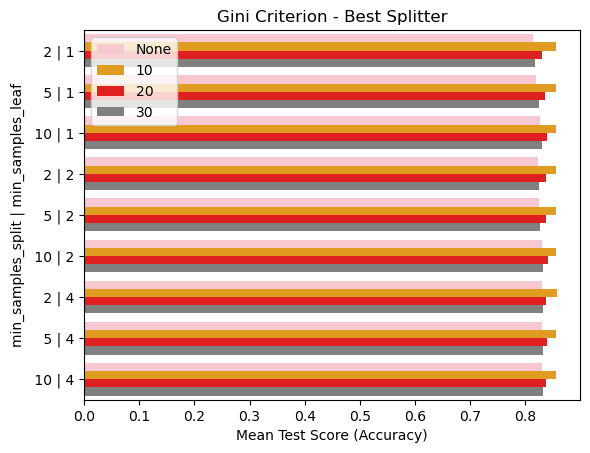

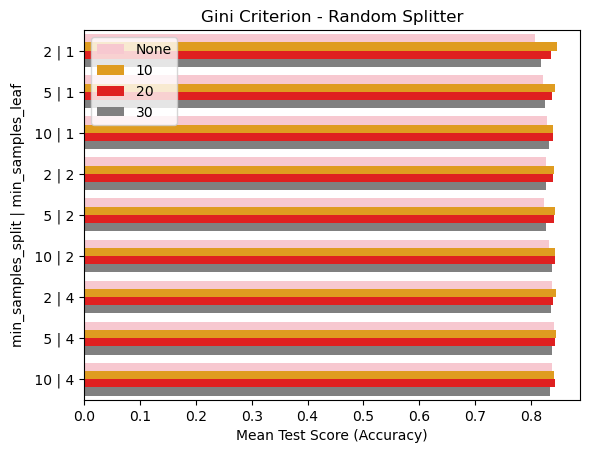

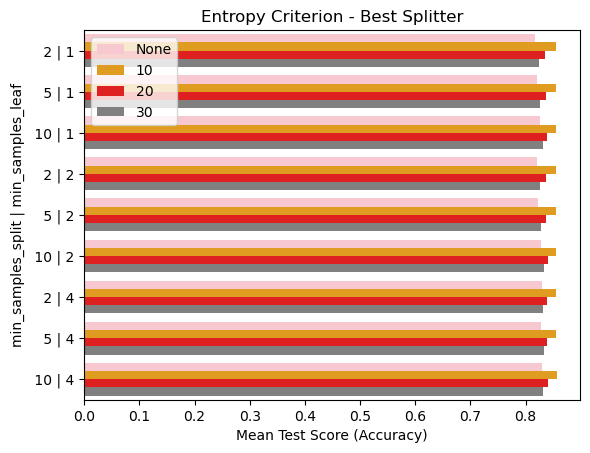

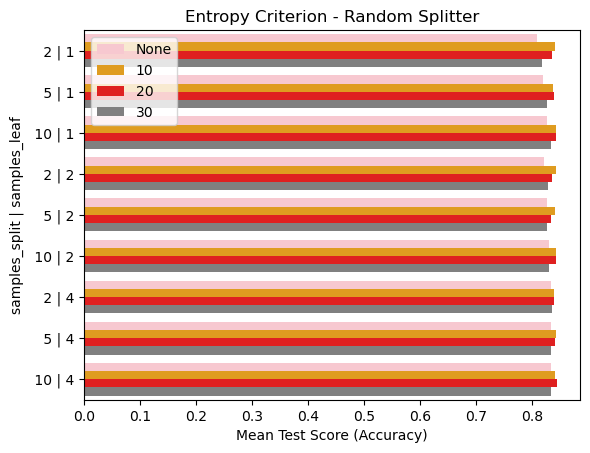

Execution Time: 82.5571517944336 seconds


In [276]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn import metrics
import time
start_time = time.time()

dt_classifier = DecisionTreeClassifier()
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

#results
results = pd.DataFrame(grid_search.cv_results_)
best_params = grid_search.best_params_
print("\nBest Hyperparameters:", best_params)

# Fit the model
best_dt_classifier = DecisionTreeClassifier(**best_params)
best_dt_classifier.fit(X_train, y_train)

# Evaluate the model 
y_pred = best_dt_classifier.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_pred)
print("\nTest Accuracy with Best Hyperparameters:", test_accuracy)


results['params_str'] = results.apply(lambda row: f" {row['param_min_samples_split']} | {row['param_min_samples_leaf']}", axis=1)
results['param_max_depth'] = results['param_max_depth'].apply(lambda x: str(x) if x is not None else 'None')
max_depth_colors = {'None': 'pink', '10': 'orange', '20': 'red', '30': 'grey'}

sns.barplot(x='mean_test_score', y='params_str', hue='param_max_depth', data=results.loc[(results['param_criterion']=='gini') & (results['param_splitter']=='best')], palette=max_depth_colors)
plt.title('Gini Criterion - Best Splitter')
plt.xlabel('Mean Test Score (Accuracy)')
plt.ylabel('min_samples_split | min_samples_leaf')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.show()

sns.barplot(x='mean_test_score', y='params_str', hue='param_max_depth', data=results.loc[(results['param_criterion']=='gini') & (results['param_splitter']=='random')], palette=max_depth_colors)
plt.title('Gini Criterion - Random Splitter')
plt.xlabel('Mean Test Score (Accuracy)')
plt.ylabel('min_samples_split | min_samples_leaf')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.show()


sns.barplot(x='mean_test_score', y='params_str', hue='param_max_depth', data=results.loc[(results['param_criterion']=='entropy') & (results['param_splitter']=='best')], palette=max_depth_colors)
plt.title('Entropy Criterion - Best Splitter')
plt.xlabel('Mean Test Score (Accuracy)')
plt.ylabel('min_samples_split | min_samples_leaf')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.show()


sns.barplot(x='mean_test_score', y='params_str', hue='param_max_depth', data=results.loc[(results['param_criterion']=='entropy') & (results['param_splitter']=='random')], palette=max_depth_colors)
plt.title('Entropy Criterion - Random Splitter')
plt.xlabel('Mean Test Score (Accuracy)')
plt.ylabel('samples_split | samples_leaf')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.show()

end_time = time.time()
execution_time1 = end_time - start_time
print(f"Execution Time: {execution_time1} seconds")


## 2- Bagging


Best Hyperparameters for Bagging: {'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 30}

Test Accuracy with Best Hyperparameters for Bagging: 0.8581782445795713

Results Table for Bagging with Columns:
    n_estimators  max_samples  max_features  mean_test_score
8             30          1.0           0.7         0.860140
2             30          0.7           0.7         0.859495
5             30          0.8           0.7         0.859341
11            30          0.7           0.8         0.857867
4             20          0.8           0.7         0.857590
7             20          1.0           0.7         0.857468
10            20          0.7           0.8         0.857222
14            30          0.8           0.8         0.857099
17            30          1.0           0.8         0.856608
1             20          0.7           0.7         0.856147
16            20          1.0           0.8         0.855502
6             10          1.0           0.7         0.855

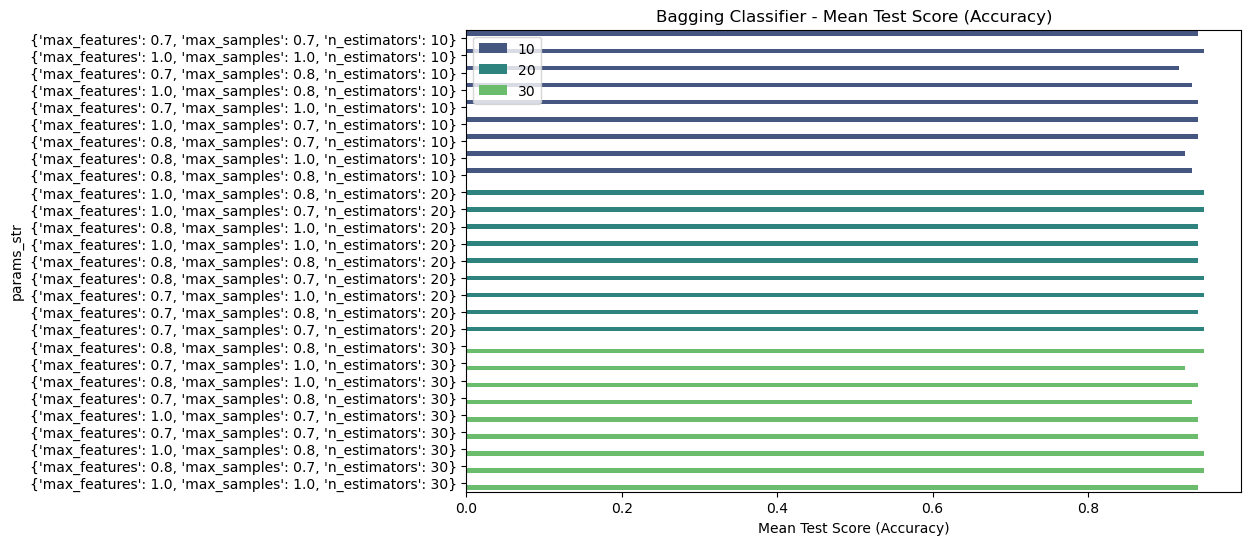

<Figure size 1000x600 with 0 Axes>

Execution Time: 189.71993589401245 seconds


In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn import metrics
import time


start_time = time.time()
base_classifier = DecisionTreeClassifier()
bagging_classifier = BaggingClassifier(base_classifier)

param_grid = {
    'n_estimators': [10, 20, 30],
    'max_samples': [0.7, 0.8, 1.0],
    'max_features': [0.7, 0.8, 1.0],
}

grid_search_bagging = GridSearchCV(bagging_classifier, param_grid, cv=5, scoring='accuracy')
grid_search_bagging.fit(X_train, y_train)

# grid search results
results_bagging = pd.DataFrame(grid_search_bagging.cv_results_)

best_params_bagging = grid_search_bagging.best_params_
print("\nBest Hyperparameters for Bagging:", best_params_bagging)

# Fit the model
best_bagging_classifier = BaggingClassifier(base_classifier, **best_params_bagging)
best_bagging_classifier.fit(X_train, y_train)

# Evaluate the model 
y_pred_bagging = best_bagging_classifier.predict(X_test)
test_accuracy_bagging = metrics.accuracy_score(y_test, y_pred_bagging)
print("\nTest Accuracy with Best Hyperparameters for Bagging:", test_accuracy_bagging)

# table
results_table_bagging = results_bagging[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)
table_columns = ['n_estimators', 'max_samples', 'max_features', 'mean_test_score']
tt = results_table_bagging.copy()
tt['n_estimators'] = tt['params'].apply(lambda x: x['n_estimators'])
tt['max_samples'] = tt['params'].apply(lambda x: x['max_samples'])
tt['max_features'] = tt['params'].apply(lambda x: x['max_features'])
tt = tt[table_columns]

print("\nResults Table for Bagging:")
print(tt)


#plot
plt.figure(figsize=(10, 6))
sns.barplot(x='mean_test_score', y='params_str', hue='param_n_estimators', data=results_bagging_sorted, palette='viridis')
plt.title('Bagging Classifier - Mean Test Score (Accuracy)')
plt.xlabel('Mean Test Score (Accuracy)')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.figure(figsize=(10, 6))
results_bagging['params_str'] = results_bagging['params'].astype(str)
results_bagging_sorted = results_bagging.sort_values(by='param_n_estimators')
plt.show()

end_time = time.time()
execution_time2 = end_time - start_time
print(f"Execution Time: {execution_time2} seconds")


## 3- Adaboost


Best Hyperparameters for AdaBoost: {'learning_rate': 0.01, 'n_estimators': 100}

Test Accuracy with Best Hyperparameters for AdaBoost: 0.8148148148148148


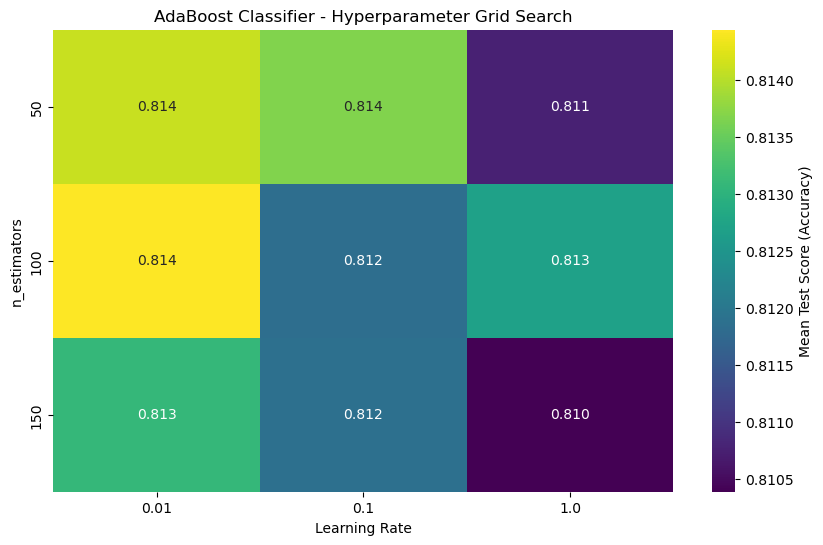

Execution Time: 474.9319441318512 seconds


In [278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn import metrics

import time
start_time = time.time()

base_dt_classifier = DecisionTreeClassifier()
adaboost_classifier = AdaBoostClassifier(base_dt_classifier)

param_grid_adaboost = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1.0],
}

grid_search_adaboost = GridSearchCV(adaboost_classifier, param_grid_adaboost, cv=5, scoring='accuracy')
grid_search_adaboost.fit(X_train, y_train)

# results
results_adaboost = pd.DataFrame(grid_search_adaboost.cv_results_)
best_params_adaboost = grid_search_adaboost.best_params_
print("\nBest Hyperparameters for AdaBoost:", best_params_adaboost)

# Fit the model
best_adaboost_classifier = AdaBoostClassifier(base_dt_classifier, **best_params_adaboost)
best_adaboost_classifier.fit(X_train, y_train)

# Evaluate the model
y_pred_adaboost = best_adaboost_classifier.predict(X_test)
test_accuracy_adaboost = metrics.accuracy_score(y_test, y_pred_adaboost)
print("\nTest Accuracy with Best Hyperparameters for AdaBoost:", test_accuracy_adaboost)

# heatmap
results_adaboost_heatmap = results_adaboost.pivot_table(index='param_n_estimators', columns='param_learning_rate', values='mean_test_score')
plt.figure(figsize=(10, 6))
sns.heatmap(results_adaboost_heatmap, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Mean Test Score (Accuracy)'})
plt.title('AdaBoost Classifier - Hyperparameter Grid Search')
plt.xlabel('Learning Rate')
plt.ylabel('n_estimators')
plt.show()

end_time = time.time()
execution_time3 = end_time - start_time
print(f"Execution Time: {execution_time3} seconds")

## 4 Gradient Boosting

In [279]:
import numpy as np
import pandas as pd
from tabulate import tabulate
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import load_iris
from sklearn import metrics
import time
start_time = time.time()

gb_classifier = GradientBoostingClassifier()

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(gb_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# results
results = pd.DataFrame(grid_search.cv_results_)
best_params = grid_search.best_params_
print("\nBest Hyperparameters:", best_params)

# Fit the model 
best_gb_classifier = GradientBoostingClassifier(**best_params)
best_gb_classifier.fit(X_train, y_train)

# Evaluate the model 
y_pred = best_gb_classifier.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_pred)
print("\nTest Accuracy with Best Hyperparameters:", test_accuracy)


# top 20 
top_results = results.nlargest(20, 'mean_test_score')
top_results = top_results.rename(columns={
    'param_n_estimators': 'n_est',
    'param_learning_rate': 'learning_rt',
    'param_max_depth': 'max_depth',
    'param_min_samples_split': 'min_split',
    'param_min_samples_leaf': 'min_leaf'
})

table_columns = ['n_est', 'learning_rt', 'max_depth', 'min_split', 'min_leaf', 'mean_test_score']
table = top_results[table_columns].copy()
table['mean_test_score'] = table['mean_test_score'].map('{:.2%}'.format)
table_str = tabulate(table, headers='keys', tablefmt='pretty', showindex=False)
print("\nTop 20 Results:")
print(table_str)


end_time = time.time()
execution_time4 = end_time - start_time
print(f"\nExecution Time: {execution_time4} seconds")



Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Test Accuracy with Best Hyperparameters: 0.8747005712179842

Top 20 Results:
+-------+-------------+-----------+-----------+----------+-----------------+
| n_est | learning_rt | max_depth | min_split | min_leaf | mean_test_score |
+-------+-------------+-----------+-----------+----------+-----------------+
|  100  |     0.2     |     5     |     5     |    2     |     87.40%      |
|  100  |     0.2     |     5     |     2     |    4     |     87.39%      |
|  100  |     0.2     |     5     |    10     |    2     |     87.39%      |
|  100  |     0.2     |     5     |     5     |    4     |     87.39%      |
|  150  |     0.2     |     4     |    10     |    4     |     87.34%      |
|  150  |     0.1     |     5     |     2     |    4     |     87.34%      |
|  100  |     0.2     |     5     |     2     |    2     |     87.33%      |
|  150  |     0.1     

## 5- Random Forest

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from tabulate import tabulate
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
from sklearn import metrics
import time

start_time = time.time()

rf_classifier = RandomForestClassifier()
param_grid = {
    'n_estimators': [50, 100, 150],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'] 
}
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)
best_params = grid_search.best_params_
print("\nBest Hyperparameters:", best_params)

# Fit the model 
best_rf_classifier = RandomForestClassifier(**best_params)
best_rf_classifier.fit(X_train, y_train)

# Evaluate 
y_pred = best_rf_classifier.predict(X_test)
test_accuracy = metrics.accuracy_score(y_test, y_pred)
print("\nTest Accuracy with Best Hyperparameters:", test_accuracy)

# Get the top 20 results 
top_results_rf = results.nlargest(20, 'mean_test_score')

top_results_rf = top_results_rf.rename(columns={
    'param_n_estimators': 'n_est',
    'param_criterion': 'criterion',
    'param_max_depth': 'max_dpth',
    'param_min_samples_split': 'min_splt',
    'param_min_samples_leaf': 'min_leaf',
    'param_max_features': 'max_features'
})

# table
table_columns_rf = ['n_est', 'criterion', 'max_dpth', 'min_splt', 'min_leaf', 'max_features', 'mean_test_score']
table_rf = top_results_rf[table_columns_rf].copy()
table_rf['mean_test_score'] = table_rf['mean_test_score'].map('{:.2%}'.format)
table_str_rf = tabulate(table_rf, headers='keys', tablefmt='pretty', showindex=False)
print("\nTop 20 Results for RandomForestClassifier:")
print(table_str_rf)

end_time = time.time()
execution_time5 = end_time - start_time
print(f"\nExecution Time: {execution_time5} seconds")

## REFLECTION:
For Decision Tree, Bagging, AdaBoost, Gradient Boosting, Random Forest:
I employed GridSearch to identify the optimal combination of hyperparameters, trained the models on the training data, and assessed their performance on the test data. To ensure reliability, I conducted 5-fold cross-validation. Visualization was facilitated through graphs or tables, aiding in the representation and comparison of results.

### The best parameters and accuracies are as below. 
### For Decision Tree
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
Test Accuracy with Best Hyperparameters: 0.8613107302991216

### Bagging
Best Hyperparameters for Bagging: {'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 30}
Test Accuracy with Best Hyperparameters for Bagging: 0.8581782445795713

### AdaBoost
Best Hyperparameters for AdaBoost: {'learning_rate': 0.01, 'n_estimators': 100}
Test Accuracy with Best Hyperparameters for AdaBoost: 0.8148148148148148


### Gradient Boosting
Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Test Accuracy with Best Hyperparameters: 0.8747005712179842

### Random Forest



When we compare the timing and the accuracies: 

In [ ]:
from tabulate import tabulate
a1 = 0.861
a2 = 0.858
a3 = 0.815
a4 = 0.874
a5 = 0.888

t1 = execution_time1
t2 = execution_time2
t3 = execution_time3
t4 = execution_time4
t5 = execution_time5

table_data = [
    ['Decision Tree', a1, t1],
    ['Bagging', a2, t2],
    ['AdaBoost', a3, t3],
    ['Gradient Boosting', a4, t4],
    ['Random Forest', a5, t5]
]

headers = ['Model', 'Accuracy', 'Execution Time (seconds)']
print(tabulate(table_data, headers=headers, tablefmt='pretty'))

## (e) Interpretation

Interpret the best performing model from model family. Plot the classi cation tree
and examine the feature importance measures for each approach. Do all methods deem similar features important? Discuss your interpretations.

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming best_gb_classifier is your trained Gradient Boosting classifier with the best hyperparameters
best_gb_classifier = GradientBoostingClassifier(learning_rate=0.2, max_depth=5, min_samples_leaf=2, min_samples_split=5, n_estimators=100)
best_gb_classifier.fit(X_train, y_train)

# Plotting the first tree (you can modify this based on the number of trees in your ensemble)
plt.figure(figsize=(20, 10))
plot_tree(best_gb_classifier.estimators_[0, 0], feature_names=X_train.columns, filled=True, rounded=True, class_names=['0', '1'])
plt.show()


In [ ]:
# Assuming X_train is your training feature set
feature_importance = best_gb_classifier.feature_importances_

# Create a DataFrame to organize feature names and their importance scores
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})

# Sort the DataFrame by importance scores for better visualization
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Gradient Boosting Feature Importance')
plt.show()
